# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.3.5
pandas version: 2.3.3
matplotlib version: 3.10.6
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

df = pd.read_parquet('../data/trip_records/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [5]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
data_dir = '../data/trip_records'

# Create a list of all the twelve files to read
file_list = [f for f in os.listdir(data_dir) if f.endswith('.parquet')]

# initialise an empty dataframe
sampled_dfs = []

print("Starting sampling process...")

for file_name in file_list:
    try:
        # Construct the file path for the current file
        file_path = os.path.join(data_dir, file_name)
        # 1. Read the current month's file
        month_df = pd.read_parquet(file_path)
        # 2. Ensure the datetime column is in the correct format
        month_df['tpep_pickup_datetime'] = pd.to_datetime(month_df['tpep_pickup_datetime'])
        
        # 3. Create temporary columns for Date and Hour
        month_df['pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['pickup_hour'] = month_df['tpep_pickup_datetime'].dt.hour
        
        # 4. Group by the date and hour, then sample 5% (frac=0.05)
        # Stratified sampling ensures our sampled data represents overall patterns accurately
        sampled_month = month_df.groupby(['pickup_date', 'pickup_hour']).sample(frac=0.05, random_state=42)
        
        # 5. Drop the temporary grouping columns to keep the dataframe clean
        sampled_month = sampled_month.drop(columns=['pickup_date', 'pickup_hour'])
        
        # 6. Append to our list
        sampled_dfs.append(sampled_month)
        
        print(f"Successfully sampled {len(sampled_month)} rows from {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        
if sampled_dfs:
    df = pd.concat(sampled_dfs, ignore_index=True)
    print(f"\nSampling complete! Final sampled dataframe shape: {df.shape}")
else:
    print("\nNo data was sampled.")

Starting sampling process...
Successfully sampled 166709 rows from 2023-12.parquet
Successfully sampled 162910 rows from 2023-6.parquet
Successfully sampled 174068 rows from 2023-7.parquet
Successfully sampled 144458 rows from 2023-5.parquet
Successfully sampled 165133 rows from 2023-11.parquet
Successfully sampled 174255 rows from 2023-10.parquet
Successfully sampled 139641 rows from 2023-4.parquet
Successfully sampled 152087 rows from 2023-1.parquet
Successfully sampled 143782 rows from 2023-8.parquet
Successfully sampled 14674 rows from sampled_2023_data.parquet
Successfully sampled 140875 rows from 2023-9.parquet
Successfully sampled 168696 rows from 2023-2.parquet
Successfully sampled 163786 rows from 2023-3.parquet

Sampling complete! Final sampled dataframe shape: (1911074, 20)


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [8]:
# Store the df in parquet
# df.to_parquet('')
if len(df) > 300000:
    df_final = df.sample(n=300000, random_state=42)
else:
    df_final = df
save_path = '../data/trip_records/sampled_2023_data.parquet'
df_final.to_parquet(save_path, index=False)
print(f"Data saved successfully with {len(df_final):,} rows.")


Data saved successfully with 300,000 rows.


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [9]:
# Load the new data file
df = pd.read_parquet(save_path)


In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-10-23 12:11:20,2023-10-23 13:03:54,1.0,6.00,99.0,N,235,43,1,23.5,0.0,0.5,0.00,0.00,1.0,25.00,0.0,0.00,NaN
1,2,2023-02-08 20:48:35,2023-02-08 21:30:00,2.0,17.66,2.0,N,132,233,1,70.0,0.0,0.5,16.11,6.55,1.0,97.91,2.5,1.25,NaN
2,2,2023-06-02 19:25:50,2023-06-02 19:37:03,1.0,1.13,1.0,N,140,229,1,11.4,2.5,0.5,1.00,0.00,1.0,18.90,2.5,0.00,NaN
3,2,2023-08-29 18:04:29,2023-08-29 18:23:37,2.0,1.78,1.0,N,68,161,2,17.0,2.5,0.5,0.00,0.00,1.0,23.50,2.5,0.00,NaN
4,2,2023-02-03 20:00:53,2023-02-03 20:09:59,3.0,0.87,1.0,N,161,50,1,9.3,2.5,0.5,0.00,0.00,1.0,15.80,2.5,0.00,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289613 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289613 non-null  float64       
 6   store_and_fwd_flag     289613 non-null  object        
 7   PULocationID           300000 non-null  int64         
 8   DOLocationID           300000 non-null  int64         
 9   payment_type           300000 non-null  int64         
 10  fare_amount            300000 non-null  float64       
 11  extra                  300000 non-null  float64       
 12  mta_tax                300000 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [12]:
# Fix the index and drop any columns that are not needed
# below columns are not needed for the analysis 
# store_and_fwd_flag : indicates if trip record was held in
# vehicle memory before sending to the server 
# mta_tax : value is constant, need variability 
# tolls_amount: this is not applicable for every trip, not relevant
columns_to_drop = ['store_and_fwd_flag', 'mta_tax', 'tolls_amount']
df.drop(columns=columns_to_drop, inplace=True)
df.head()
df.columns


Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'tip_amount',
       'improvement_surcharge', 'total_amount', 'congestion_surcharge',
       'Airport_fee', 'airport_fee'],
      dtype='object')


# Fix data type of column 
From the table above, we can observe that a few columns do not have the correct data types and need to be fixed:

- `RatecodeID` is currently stored as `float64`, but according to the data dictionary it contains categorical values such as 1, 2, 3, 4, 5, and 6. Therefore, it should be converted to an integer type.
- `passenger_count` is also stored as `float64`, but the number of passengers cannot be in decimal form, so it should be converted to `int64`.


In [13]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289753 non-null  float64       
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289753 non-null  float64       
 6   PULocationID           300000 non-null  int64         
 7   DOLocationID           300000 non-null  int64         
 8   payment_type           300000 non-null  int64         
 9   fare_amount            300000 non-null  float64       
 10  extra                  300000 non-null  float64       
 11  tip_amount             300000 non-null  float64       
 12  improvement_surcharge  300000 non-null  floa

In [14]:
# Fix the data types of the columns
df['RatecodeID'] = df['RatecodeID'].astype('Int64')
df['passenger_count'] = df['passenger_count'].astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        289753 non-null  Int64         
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             289753 non-null  Int64         
 6   PULocationID           300000 non-null  int64         
 7   DOLocationID           300000 non-null  int64         
 8   payment_type           300000 non-null  int64         
 9   fare_amount            300000 non-null  float64       
 10  extra                  300000 non-null  float64       
 11  tip_amount             300000 non-null  float64       
 12  improvement_surcharge  300000 non-null  floa

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [15]:
# Combine the two airport fee columns
df["airport_fee"].fillna(0.0, inplace=True)
df["Airport_fee"].fillna(0.0, inplace=True)
# Combine the two airport fee columns into a single column
df['airport_fee_combined'] = df['airport_fee'] + df['Airport_fee']
# Drop the original airport fee columns
df.drop(['airport_fee', 'Airport_fee'], axis=1, inplace=True)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
0,1,2023-06-14 12:32:12,2023-06-14 12:43:29,1,2.10,1,43,42,1,13.5,2.5,2.00,1.0,19.50,2.5,0.0
1,2,2023-04-27 21:31:05,2023-04-27 21:40:34,1,1.50,1,48,229,1,10.7,1.0,3.14,1.0,18.84,2.5,0.0
2,2,2023-11-02 18:28:42,2023-11-02 18:41:04,2,1.62,1,170,237,1,12.8,2.5,3.86,1.0,23.16,2.5,0.0
3,2,2023-04-26 10:16:38,2023-04-26 10:54:31,1,19.77,4,170,1,1,134.6,0.0,0.00,1.0,151.35,2.5,0.0
4,2,2023-01-18 11:29:17,2023-01-18 11:37:59,1,1.33,1,161,236,1,10.0,0.0,2.80,1.0,16.80,2.5,0.0


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [16]:
# check where values of fare amount are negative
#  as you see in the output fare amount doesn't have negative value 
#  i am checking for all the columns, 
negativeValuePercentage  = pd.DataFrame({
    'Column': df.columns.values,
    'Negative-Value(%)': [len(df[col][df[col] < 0]) / len(df) * 100 if col in df.select_dtypes(include=[np.number]).columns else 0 for col in df.columns]
}).round(3)
negativeValuePercentage


,Column,Negative-Value(%)
0,VendorID,0.000
1,tpep_pickup_datetime,0.000
2,tpep_dropoff_datetime,0.000
3,passenger_count,0.000
4,trip_distance,0.000
5,RatecodeID,0.000
6,PULocationID,0.000
7,DOLocationID,0.000
8,payment_type,0.000
9,fare_amount,0.000


Let's fix the columns with native values:
- `improvement_surcharge`
- `total_amount`
- `congestion_surcharge`
- `airport_fee_combined`

We will replace the negative values with the absolute value of that column.

In [17]:
# Replace negative values in the negative columns with the absolute value
negative_cols = ['improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee_combined']
for col in negative_cols:
    df.loc[df[col] < 0, col] = df[col].abs()
    
df.head()



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
0,1,2023-06-14 12:32:12,2023-06-14 12:43:29,1,2.10,1,43,42,1,13.5,2.5,2.00,1.0,19.50,2.5,0.0
1,2,2023-04-27 21:31:05,2023-04-27 21:40:34,1,1.50,1,48,229,1,10.7,1.0,3.14,1.0,18.84,2.5,0.0
2,2,2023-11-02 18:28:42,2023-11-02 18:41:04,2,1.62,1,170,237,1,12.8,2.5,3.86,1.0,23.16,2.5,0.0
3,2,2023-04-26 10:16:38,2023-04-26 10:54:31,1,19.77,4,170,1,1,134.6,0.0,0.00,1.0,151.35,2.5,0.0
4,2,2023-01-18 11:29:17,2023-01-18 11:37:59,1,1.33,1,161,236,1,10.0,0.0,2.80,1.0,16.80,2.5,0.0


<!-- Did you notice something different in the `RatecodeID` column for above records? -->

In [18]:
# Analyse RatecodeID for the negative fare amounts


# Filter the DataFrame for negative fare_amount
negative_fare_df = df[df['fare_amount'] < 0]

# Analyze the distribution of RatecodeID for negative fare_amount
ratecode_analysis = negative_fare_df['RatecodeID'].value_counts()

# Display the analysis
print(ratecode_analysis)

Series([], Name: count, dtype: Int64)


In [19]:
# Find which columns have negative values
pd.DataFrame({
    'Column': df.columns.values,
    'Negative-Value(%)': [len(df[col][df[col] < 0]) / len(df) * 100 if col in df.select_dtypes(include=[np.number]).columns else 0 for col in df.columns]
}).round(3)


,Column,Negative-Value(%)
0,VendorID,0.0
1,tpep_pickup_datetime,0.0
2,tpep_dropoff_datetime,0.0
3,passenger_count,0.0
4,trip_distance,0.0
5,RatecodeID,0.0
6,PULocationID,0.0
7,DOLocationID,0.0
8,payment_type,0.0
9,fare_amount,0.0


In [20]:
# fix these negative values

#  as per above output, no column has negative value

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




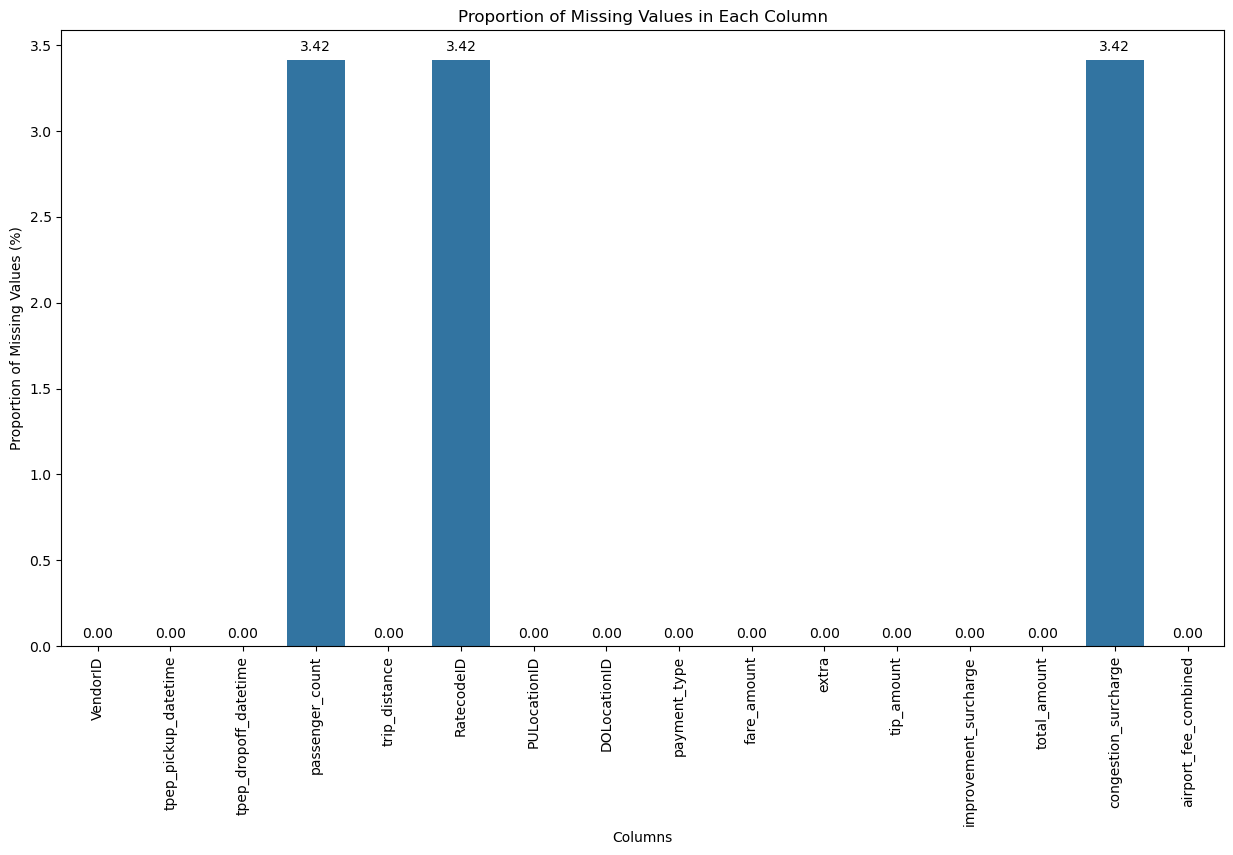

In [21]:
# Find the proportion of missing values in each column
# Use below function to show a bar plot
def show_bar_plot(x, y, title, xlabel, ylabel, figsize=(15, 8), show_data_labels=False):
    plt.figure(figsize=figsize)
    ax = sns.barplot(x=x, y=y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=90)
    
    if show_data_labels:
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')
    
    plt.show()

# Find the proportion of missing values in each column

# Calculate the proportion of missing values in each column
missing_values = df.isna().mean() * 100
show_bar_plot(missing_values.index, missing_values.values, 'Proportion of Missing Values in Each Column', 'Columns', 'Proportion of Missing Values (%)', show_data_labels=True)



**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [22]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
display(df[df['passenger_count'].isna()])

# Impute NaN values in 'passenger_count' with the median
median_passengers = df['passenger_count'].median()
df['passenger_count'] = df['passenger_count'].fillna(median_passengers)
df["passenger_count"] = df["passenger_count"].astype(int)

# Verify that there are no missing values left
print(f"Missing value (%) 'passenger_count': {df['passenger_count'].isna().mean() * 100}%")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
31,1,2023-01-22 17:58:13,2023-01-22 18:08:48,<NA>,2.70,<NA>,79,162,0,13.50,0.0,2.63,1.0,20.13,NaN,0.0
33,2,2023-10-13 18:16:27,2023-10-13 19:14:14,<NA>,18.18,<NA>,151,132,0,71.50,0.0,11.99,1.0,91.93,NaN,0.0
41,1,2023-10-20 15:45:18,2023-10-20 16:07:45,<NA>,0.00,<NA>,244,127,0,21.70,0.0,0.00,1.0,23.20,NaN,0.0
45,2,2023-10-19 13:44:00,2023-10-19 14:04:00,<NA>,7.55,<NA>,41,138,0,27.00,0.0,7.09,1.0,42.53,NaN,0.0
161,1,2023-09-09 15:17:37,2023-09-09 15:34:41,<NA>,0.00,<NA>,239,48,0,33.22,0.0,0.00,1.0,37.22,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299870,2,2023-09-06 09:15:10,2023-09-06 09:45:48,<NA>,5.38,<NA>,151,164,0,29.02,0.0,6.60,1.0,39.62,NaN,0.0
299918,2,2023-11-09 00:38:05,2023-11-09 00:51:54,<NA>,2.16,<NA>,256,37,0,14.65,0.0,0.00,1.0,16.15,NaN,0.0
299927,2,2023-06-11 15:32:00,2023-06-11 16:02:34,<NA>,5.97,<NA>,68,255,0,35.09,0.0,9.13,1.0,54.77,NaN,0.0
299937,1,2023-11-24 05:34:21,2023-11-24 05:38:46,<NA>,0.00,<NA>,241,136,0,10.33,0.0,0.00,1.0,11.83,NaN,0.0


Missing value (%) 'passenger_count': 0.0%


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [23]:
# Fix missing values in 'RatecodeID'
# For categorical data like this, the most standard way to handle missing values
# is to impute them using the mode (the most frequent value).


df['RatecodeID'].value_counts()
print(f"Missing values before: {df['RatecodeID'].isna().sum()}")
mode_val = df['RatecodeID'].mode()[0]
print(f"The most frequent RatecodeID is: {mode_val}")
# update missing value with first/highest value
df['RatecodeID'] = df['RatecodeID'].fillna(mode_val)

#Verify that there are no missing values left
print(f"Missing values after: {df['RatecodeID'].isna().sum()}")

# also i notice the RatecodeID range should be from 1 to 6 but i see 99 as well,
#  so i will be replacing this  as well, so i will now replace 99 with highest mode value 
df['RatecodeID'] = df['RatecodeID'].replace(99.0, mode_val)

df['RatecodeID'].value_counts()



Missing values before: 10247
The most frequent RatecodeID is: 1
Missing values after: 0


RatecodeID
1    285413
2     11360
5      1658
3       948
4       621
Name: count, dtype: Int64

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [24]:
# handle null values in congestion_surcharge
df['congestion_surcharge'].value_counts()
# Impute the missing values in 'congestion_surcharge' with the median value

df["congestion_surcharge"].fillna(df["congestion_surcharge"].median(), inplace=True)



Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [25]:
# Handle any remaining missing values
# No other columns found with missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               300000 non-null  int64         
 1   tpep_pickup_datetime   300000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  300000 non-null  datetime64[us]
 3   passenger_count        300000 non-null  int64         
 4   trip_distance          300000 non-null  float64       
 5   RatecodeID             300000 non-null  Int64         
 6   PULocationID           300000 non-null  int64         
 7   DOLocationID           300000 non-null  int64         
 8   payment_type           300000 non-null  int64         
 9   fare_amount            300000 non-null  float64       
 10  extra                  300000 non-null  float64       
 11  tip_amount             300000 non-null  float64       
 12  improvement_surcharge  300000 non-null  floa

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

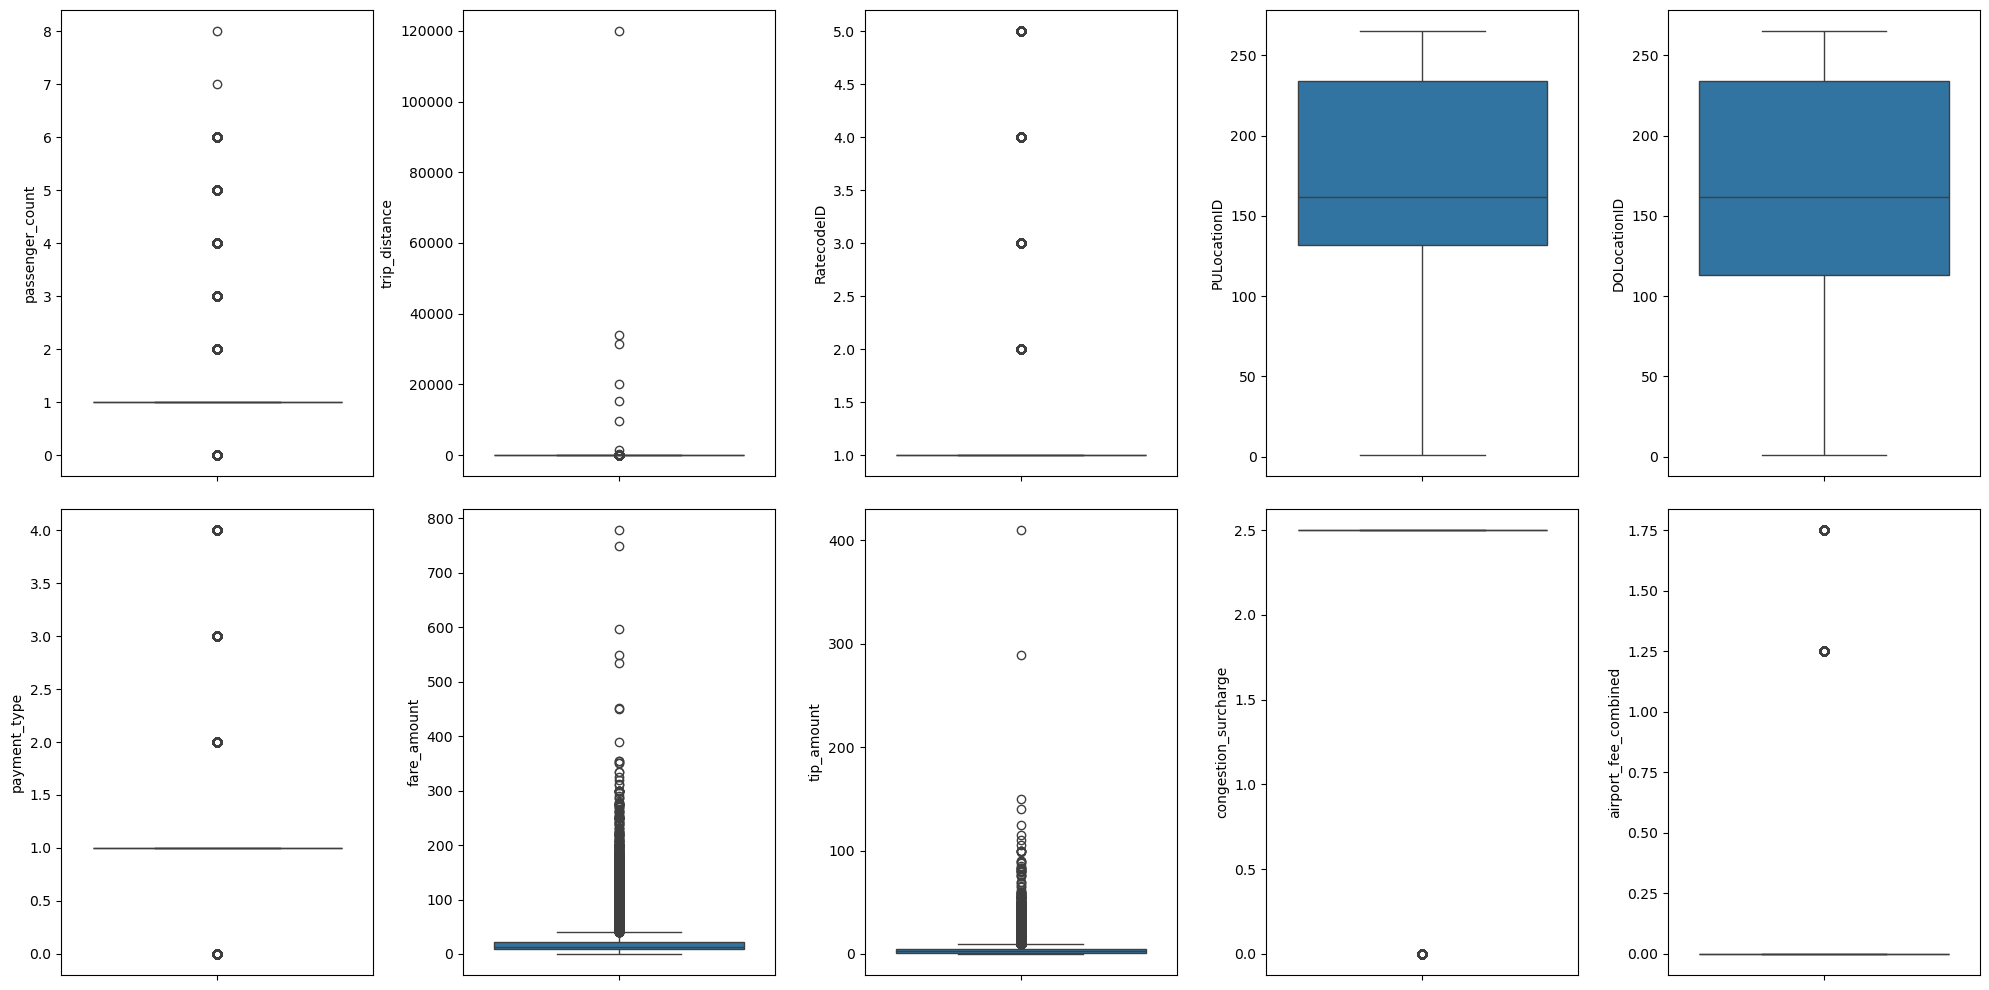

In [26]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

numerical_columns = ['passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'tip_amount', 'congestion_surcharge', 'airport_fee_combined']
numerical_columns_len = len(numerical_columns)
rows = int(len(numerical_columns) / 2)
fig, axs = plt.subplots(ncols=int(len(numerical_columns) / 2), nrows=2, figsize=(20, 2 * rows))

axs = axs.flatten() if numerical_columns_len > 1 else [axs]  # Ensure axis is iterable
for index, col in enumerate(numerical_columns):
    sns.boxplot(y=col, data=df, ax=axs[index])

plt.tight_layout(w_pad=0.5, h_pad=2)
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

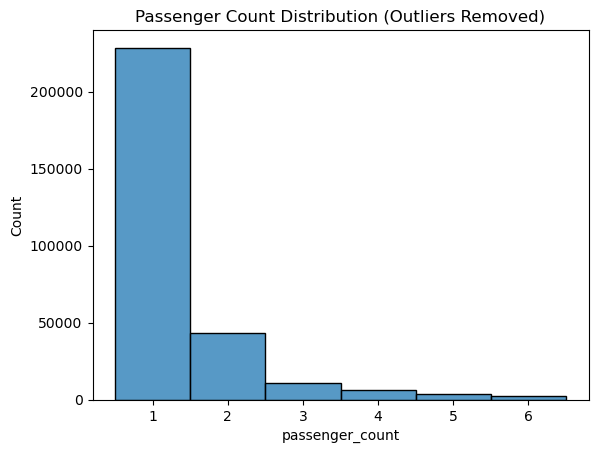

In [27]:
# remove passenger_count > 6
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]


sns.histplot(x=df['passenger_count'], discrete=True)
plt.title("Passenger Count Distribution (Outliers Removed)")
plt.show()


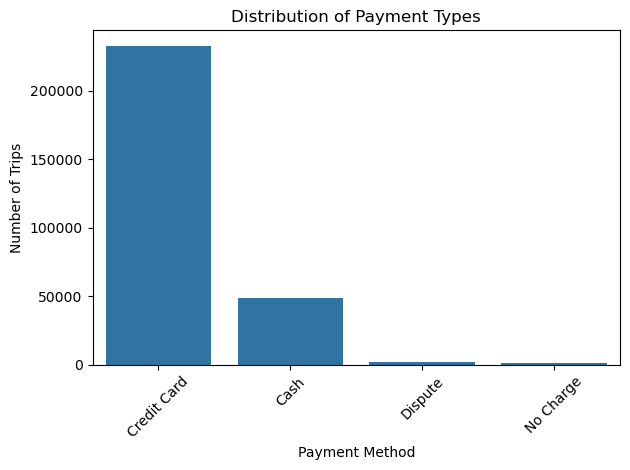

In [28]:
# Continue with outlier handling
# Remove entries where payment_type is 0
df = df[df['payment_type'] != 0]
payment_mapping = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided Trip'
}
sns.countplot(x=df['payment_type'].map(payment_mapping))

# Adding titles and rotating it in x-labels so they don't overlap
plt.title("Distribution of Payment Types")
plt.xlabel("Payment Method")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45) 

# To ensures labels don't get cut off
plt.tight_layout()

plt.show()


In [29]:
# Do any columns need standardising?

#  Standardising column names by converting them all to lowercase
df.columns = [col.lower() for col in df.columns]
print("Standardised Columns:", df.columns.tolist())
#  Standardising data types for categorical ID columns
# converting these from numbers to 'category' 
categorical_cols = ['vendorid', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
print("\nData types after standardisation:")
print(df[categorical_cols].dtypes)


Standardised Columns: ['vendorid', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type', 'fare_amount', 'extra', 'tip_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee_combined']

Data types after standardisation:
vendorid        category
ratecodeid      category
pulocationid    category
dolocationid    category
payment_type    category
dtype: object


In [30]:
# Figure out the column names based on whether we made them lowercase earlier
pu_col = 'pulocationid' if 'pulocationid' in df.columns else 'PULocationID'
do_col = 'dolocationid' if 'dolocationid' in df.columns else 'DOLocationID'
print(f"Shape before we drop these outliers: {df.shape}")
# Drop the weird trips that went nowhere but somehow cost over $300
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]
# Drop the impossible trips that claim 0 distance and 0 fare, but ended up in a
#  totally different zone!
# (I added .astype(float) here to bypass that annoying categorical error you just saw)
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df[pu_col].astype(float) != df[do_col].astype(float)))]
# Drop trips over 250 miles (these are almost certainly data entry errors)
df = df[df['trip_distance'] <= 250]
# Make sure payment type 0 is gone (since 0 doesn't exist in the official dictionary)
df = df[df['payment_type'].astype(float) != 0]
print(f"Shape after cleaning: {df.shape}")

Shape before we drop these outliers: (285106, 16)
Shape after cleaning: (285089, 16)


In [31]:
# Find rows which are not from 2023 as we are only interested in 2023 data
outlier_years = df[(df['tpep_pickup_datetime'].dt.year != 2023) | (df['tpep_dropoff_datetime'].dt.year != 2023)]
outlier_years

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
198803,2,2023-12-31 23:27:38,2024-01-01 00:07:38,2,18.79,1,132,133,1,73.0,1.0,22.65,1.0,99.90,0.0,1.75
276593,2,2023-12-31 23:17:03,2024-01-01 00:35:48,2,26.15,1,50,238,1,110.1,1.0,32.24,1.0,161.22,2.5,0.00


In [32]:
# Drop the rows which are not from 2023
df.drop(outlier_years.index, inplace=True)

In [33]:
# Find rows which are not from 2023 as we are only interested in 2023 data
outlier_years = df[(df['tpep_pickup_datetime'].dt.year != 2023) | (df['tpep_dropoff_datetime'].dt.year != 2023)]
outlier_years

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined


Handling Outliers for `trip_distance`.

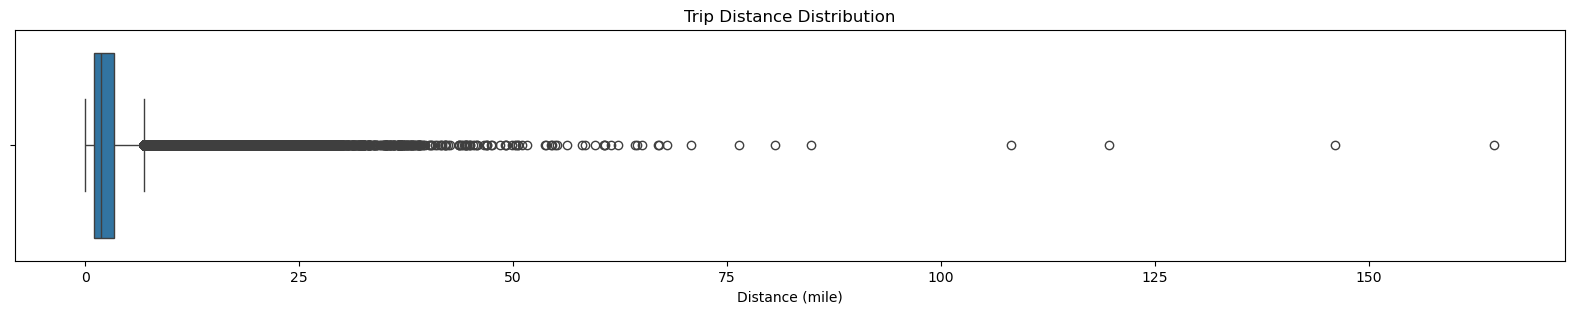

In [34]:
plt.figure(figsize=(20, 3))

sns.boxplot(data=df, x='trip_distance')
plt.xlabel('Distance (mile)')
plt.title('Trip Distance Distribution')

plt.show()

Assuming that taxis that travel less than (0.62 miles/ 1 km ) are incorrect records such as the possibility of passengers or drivers canceling orders, then datasets that have this value will be dropped.

In [35]:
outlier_suspicious_trips = df[
    (df['trip_distance'] < 0.62) &
    (df['fare_amount'] > 300)
]

print("Suspicious trips:", len(outlier_suspicious_trips))

Suspicious trips: 0


Assuming that taxis that travel more than (120 miles) are incorrect records as these are extreme outliers.

In [36]:
# Remove rows where trip_distance is more than 250 miles

df = df[df['trip_distance'] < 250]

Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)

In [37]:
#  condition for invalid trips

invalid_trip_condition = (
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (
        df['pulocationid'].cat.codes  !=
        df['dolocationid'].cat.codes 
    )
)

# checking invalid trip count 
print("Invalid trips before removing :", invalid_trip_condition.sum())
# removing invalid trip 

df = df[~invalid_trip_condition]

# checking invalid trip count after removing 
# verify removal

remaining_invalid = (
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (
        df['pulocationid'].cat.codes  !=
        df['dolocationid'].cat.codes 
    )
).sum()

print("Invalid trips after removing :", remaining_invalid)

Invalid trips before removing : 34
Invalid trips after removing : 0


Visualising after cleaning outlier

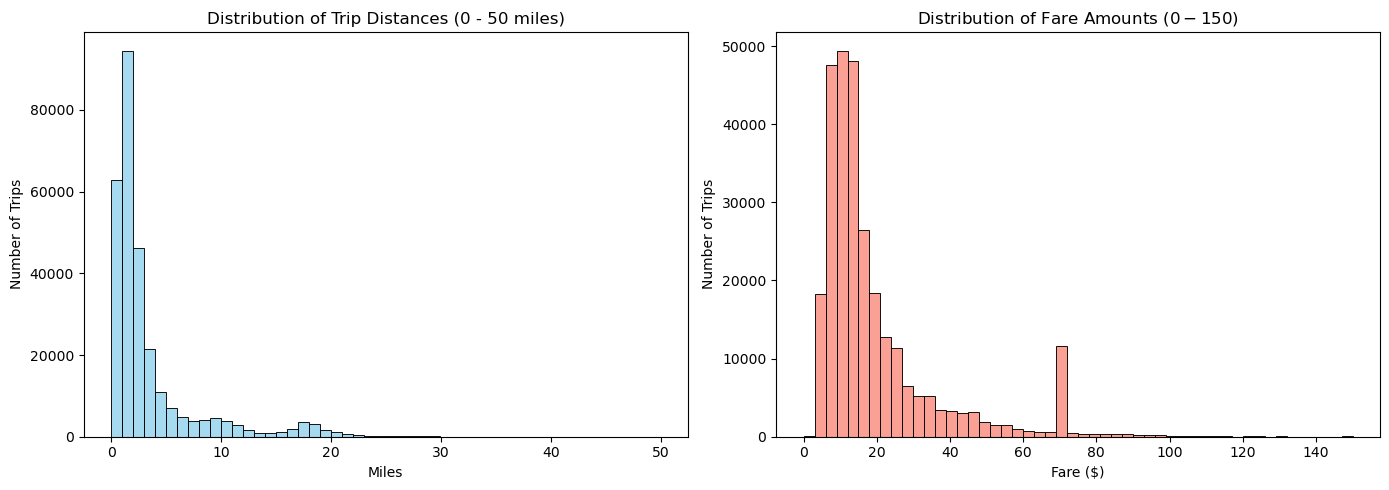

In [38]:
# Let's set up a nice wide canvas with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trip Distance Histogram
# I'm filtering it to <= 50 miles just for the plot so we can clearly see the main cluster of trips
sns.histplot(df[df['trip_distance'] <= 50]['trip_distance'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution of Trip Distances (0 - 50 miles)")
axes[0].set_xlabel("Miles")
axes[0].set_ylabel("Number of Trips")

# Fare Amount Histogram
# Filtering to <= $150 so the graph isn't squished by the handful of expensive airport runs
sns.histplot(df[df['fare_amount'] <= 150]['fare_amount'], bins=50, ax=axes[1], color='salmon')
axes[1].set_title("Distribution of Fare Amounts ($0 - $150)")
axes[1].set_xlabel("Fare ($)")
axes[1].set_ylabel("Number of Trips")
# This just makes sure the labels don't overlap with each other
plt.tight_layout()
plt.show()

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [39]:
df.columns.tolist()

['vendorid',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'ratecodeid',
 'pulocationid',
 'dolocationid',
 'payment_type',
 'fare_amount',
 'extra',
 'tip_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee_combined']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [40]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_num'] = df['tpep_pickup_datetime'].dt.day_of_week
df['pickup_month_num'] = df['tpep_pickup_datetime'].dt.month
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

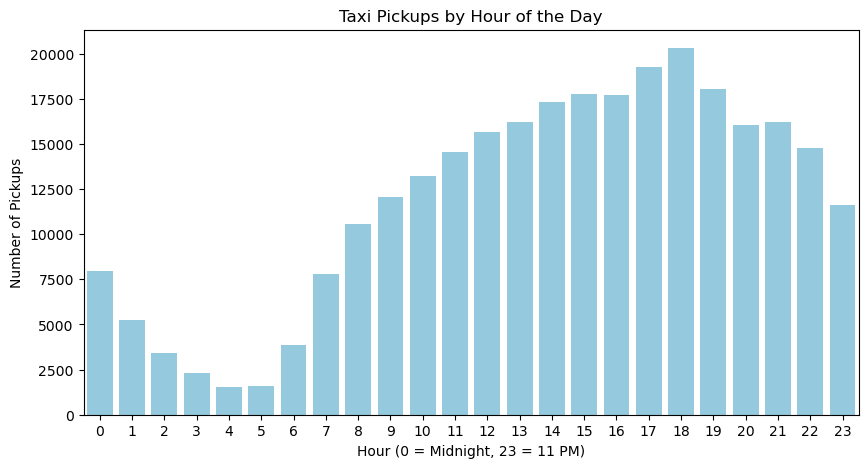

In [41]:
# Find and show the hourly trends in taxi pickups
plt.figure(figsize=(10, 5))
sns.countplot(x='pickup_hour', data=df, color='skyblue')
plt.title("Taxi Pickups by Hour of the Day")
plt.xlabel("Hour (0 = Midnight, 23 = 11 PM)")
plt.ylabel("Number of Pickups")
plt.show()


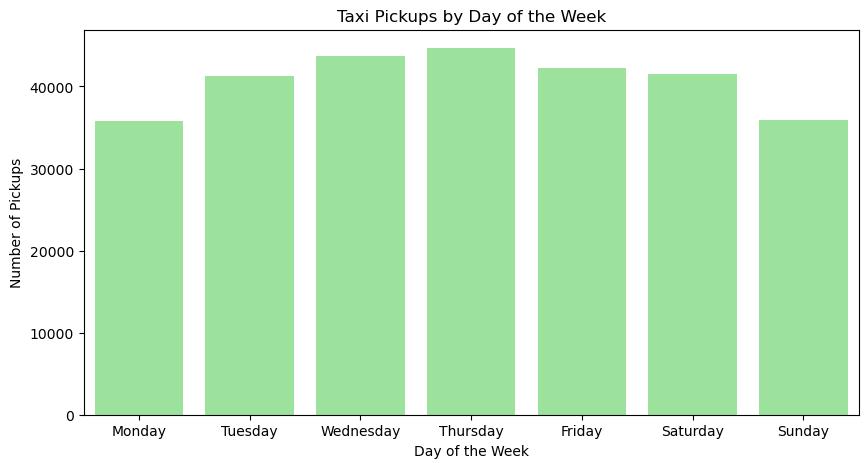

In [42]:
# Find and show the daily trends in taxi pickups (days of the week)

plt.figure(figsize=(10, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='pickup_day', data=df, order=days_order, color='lightgreen')
plt.title("Taxi Pickups by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Pickups")
plt.show()



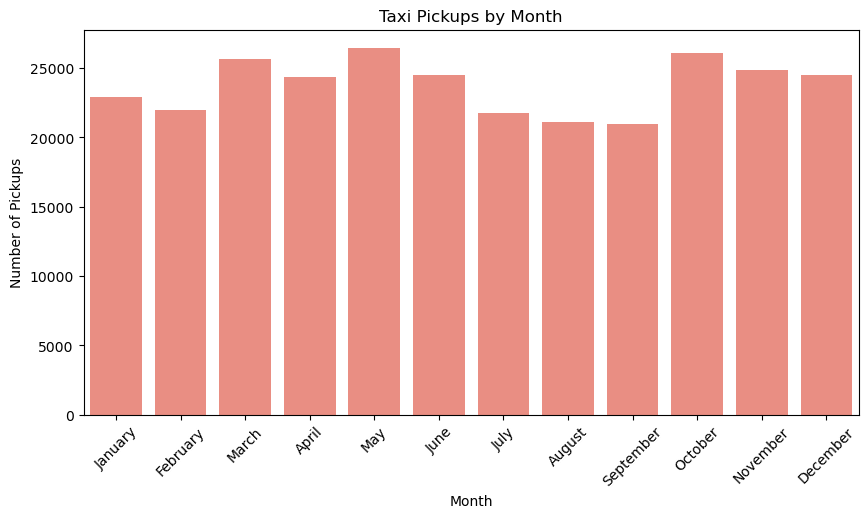

In [43]:
# Show the monthly trends in pickups
plt.figure(figsize=(10, 5))
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(x='pickup_month', data=df, order=months_order, color='salmon')
plt.title("Taxi Pickups by Month")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=45) # Tilts the month names so they fit
plt.show()



##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [44]:
# Analyse the above parameters
financial_columns = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
df[financial_columns].describe()


,fare_amount,tip_amount,total_amount,trip_distance
count,285053.000000,285053.000000,285053.000000,285053.000000
mean,19.820268,3.596070,28.975892,3.463939
std,18.357986,4.177108,23.016388,4.571069
min,0.000000,0.000000,0.000000,0.000000
25%,9.300000,1.000000,15.960000,1.060000
50%,13.500000,2.860000,21.000000,1.800000
75%,21.900000,4.480000,30.720000,3.390000
max,778.600000,410.000000,798.550000,164.660000


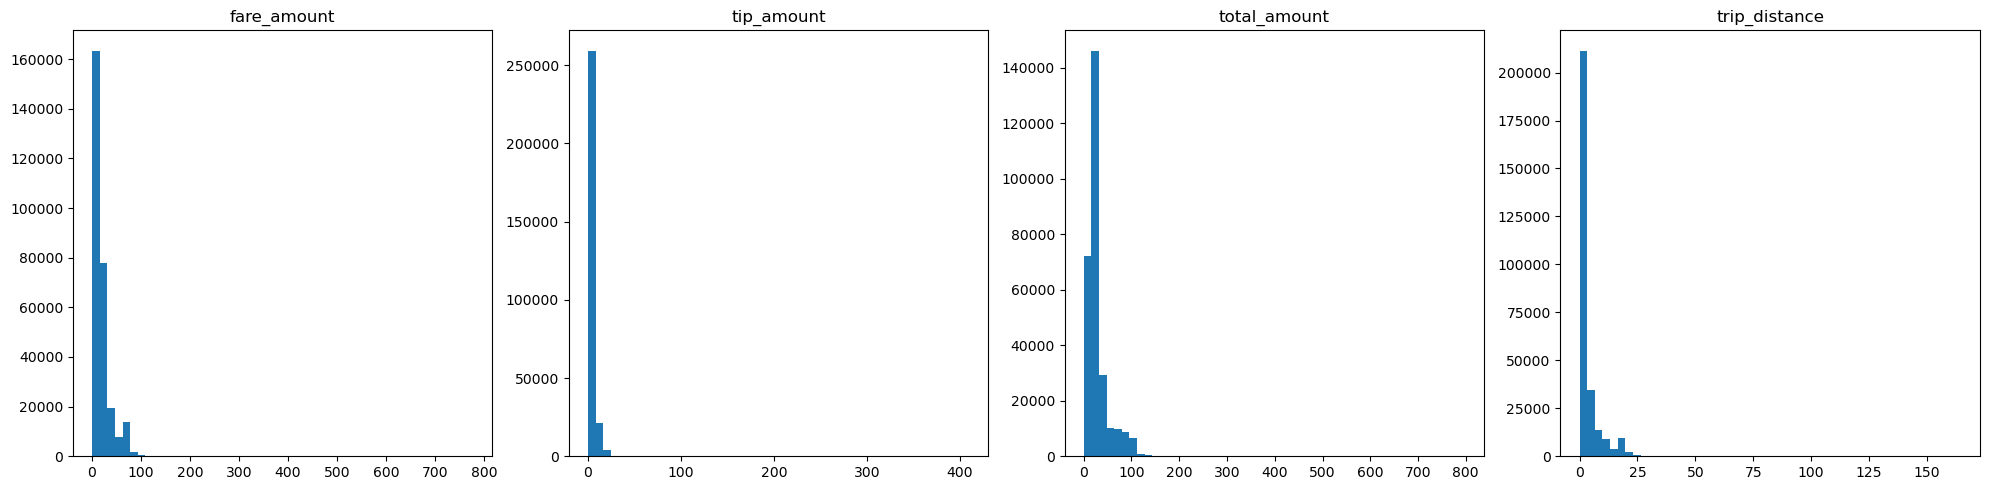

In [45]:
fig, axs = plt.subplots(ncols=4, figsize=(20, 5))

for axs, col in zip(axs.flatten(), financial_columns):
    axs.hist(df[col], bins=50)
    axs.set_title(col)

plt.tight_layout(w_pad=0.5, h_pad=2)
plt.show()

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

In [46]:
#  Yes, it is very beneficial.
#  Zero values in columns like trip_distance and fare_amount are typically recording errors
#  (e.g., the meter was engaged but the GPS failed to track movement,
#  or the passenger cancelled immediately after getting in)
#  If we include these zeros in our statistical analysis or machine learning models,
#  they act as heavy anchors—artificially pulling down our averages
#  and ruining our correlation calculations. Creating a copy of the DataFrame
#  without these zeros is the smartest approach because it allows us 
#  to analyze the "true" trips accurately, without permanently deleting the 
#  original records (which we might still want later just to count total taxi dispatches

In [47]:
df_nonzero = df[(df['fare_amount'] != 0) & (df['tip_amount'] != 0) & (df['total_amount'] != 0) & (df['trip_distance'] != 0)].copy()
print(f"Original DataFrame size: {len(df):,} trips")
print(f"Zero-free DataFrame size: {len(df_nonzero):,} trips")
print(f"Removed {len(df) - len(df_nonzero):,} problematic zero-value trips.")

Original DataFrame size: 285,053 trips
Zero-free DataFrame size: 220,480 trips
Removed 64,573 problematic zero-value trips.


**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [48]:
# Create a df with non zero entries for the selected parameters.
print(f"Total trips before filtering: {len(df):,}")
df = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)& (df['total_amount'] > 0)& (df['tip_amount'] > 0)]
print(f"Total trips after filtering: {len(df):,}")

# Display the first few rows of the new DataFrame non zero 
df_nonzero.head()

Total trips before filtering: 285,053
Total trips after filtering: 220,480


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,...,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined,pickup_hour,pickup_day_num,pickup_month_num,pickup_day,pickup_month
0,1,2023-06-14 12:32:12,2023-06-14 12:43:29,1,2.10,1,43,42,1,13.5,...,2.00,1.0,19.50,2.5,0.0,12,2,6,Wednesday,June
1,2,2023-04-27 21:31:05,2023-04-27 21:40:34,1,1.50,1,48,229,1,10.7,...,3.14,1.0,18.84,2.5,0.0,21,3,4,Thursday,April
2,2,2023-11-02 18:28:42,2023-11-02 18:41:04,2,1.62,1,170,237,1,12.8,...,3.86,1.0,23.16,2.5,0.0,18,3,11,Thursday,November
4,2,2023-01-18 11:29:17,2023-01-18 11:37:59,1,1.33,1,161,236,1,10.0,...,2.80,1.0,16.80,2.5,0.0,11,2,1,Wednesday,January
5,2,2023-09-02 19:14:37,2023-09-02 19:25:56,1,1.01,1,161,230,1,11.4,...,2.00,1.0,17.40,2.5,0.0,19,5,9,Saturday,September


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

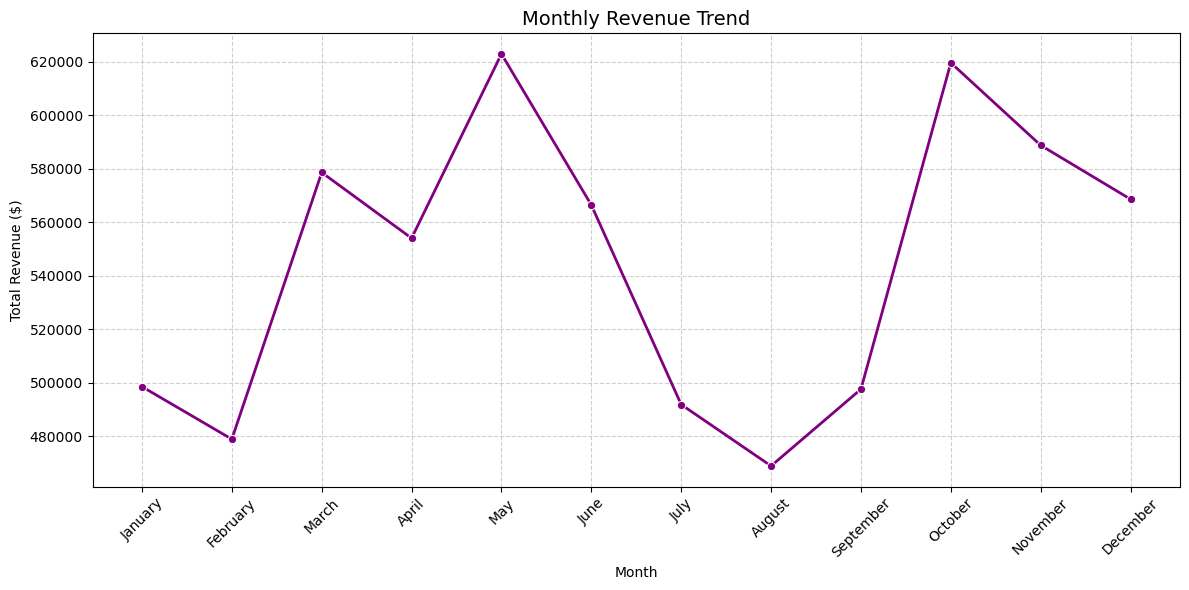

In [49]:
# Group data by month and analyse monthly revenue

#  Define the correct order of the months so the line graph goes from Jan to Dec
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
#  Group by our month column and sum up the total_amount, ordering by our months_order list
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum().reindex(months_order)
#  Create the Line Plot
plt.figure(figsize=(12, 6))
# We use marker='o' to put a little dot on each month for easier reading
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', color='purple', linewidth=2)
plt.title("Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6) # Adds a faint grid so it's easier to read the numbers
plt.tight_layout()
plt.show()



**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

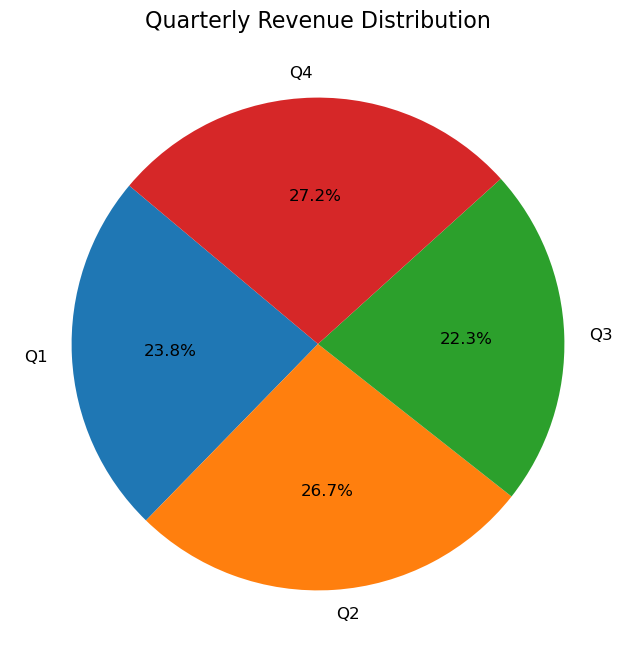

In [50]:
# Calculate proportion of each quarter

# Pandas can calculate quarters automatically from our datetime column
# Defined a function to map months to quarters
# We just add 'Q' to the front so it looks like 'Q1', 'Q2', etc.
# as we have date time, we should use date time properties
df['pickup_quarter'] = 'Q' + df['tpep_pickup_datetime'].dt.quarter.astype(str)

#  Group data by quarter and sum up the total revenue
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()


# Plot the quarterly revenue distribution using a pie chart
plt.figure(figsize=(8, 8))

plt.pie(quarterly_revenue, labels=quarterly_revenue.index, autopct='%1.1f%%', 
        startangle=140, textprops={'fontsize': 12})
plt.title('Quarterly Revenue Distribution', fontsize=16)
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

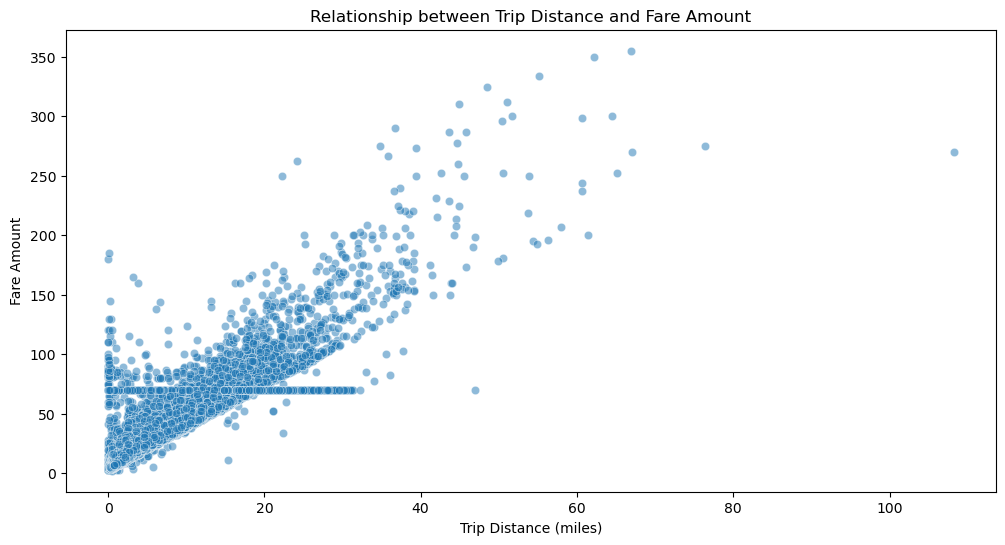

Correlation between Trip Distance and Fare Amount: 0.95


In [51]:
# Show how trip fare is affected by distance

# Use below function to show a scatter plot
def render_scatter_plot(x, y, data, title, xlabel, ylabel, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.scatterplot(x=x, y=y, data=data, alpha=0.5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# Filter out trips with trip_distance = 0
filtered_df = df_nonzero[df_nonzero['trip_distance'] > 0]

# Plot the relationship between trip_distance and fare_amount
render_scatter_plot('trip_distance', 'fare_amount', filtered_df, 'Relationship between Trip Distance and Fare Amount', 'Trip Distance (miles)', 'Fare Amount')

# Calculate the correlation value between trip_distance and fare_amount
correlation_value = filtered_df['trip_distance'].corr(filtered_df['fare_amount'])
print(f'Correlation between Trip Distance and Fare Amount: {correlation_value:.2f}')

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

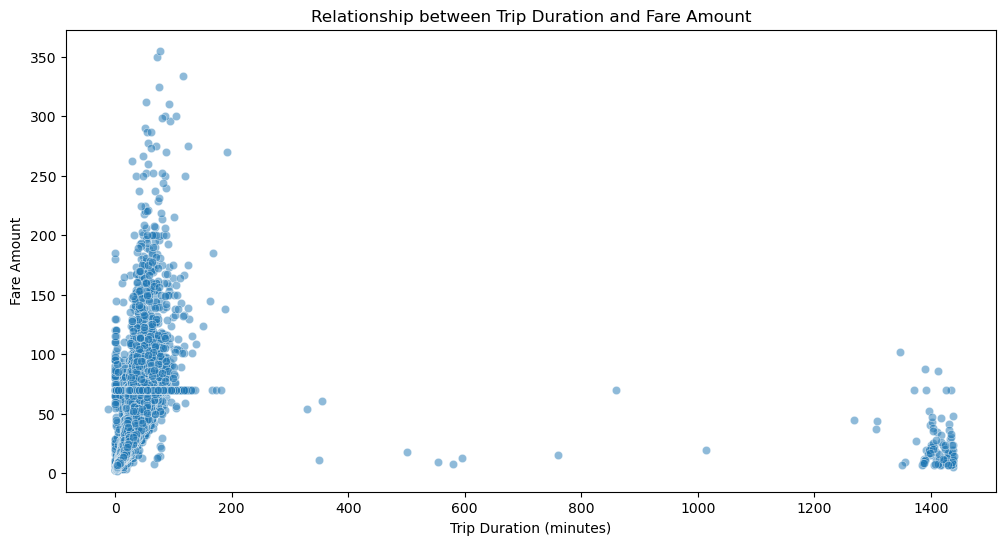

Correlation between Trip Duration and Fare Amount: 0.31


In [52]:
# Show relationship between fare and trip duration

# Calculate trip duration in minutes
df_nonzero['trip_duration_derived'] = (df_nonzero['tpep_dropoff_datetime'] - df_nonzero['tpep_pickup_datetime']).dt.total_seconds() / 60

# Plot the relationship between fare_amount and trip_duration
render_scatter_plot('trip_duration_derived', 'fare_amount', df_nonzero, 'Relationship between Trip Duration and Fare Amount', 'Trip Duration (minutes)', 'Fare Amount')

# Calculate the correlation value between trip_duration and fare_amount
correlation_value_duration_fare = df_nonzero['trip_duration_derived'].corr(df_nonzero['fare_amount'])
print(f'Correlation between Trip Duration and Fare Amount: {correlation_value_duration_fare:.2f}')


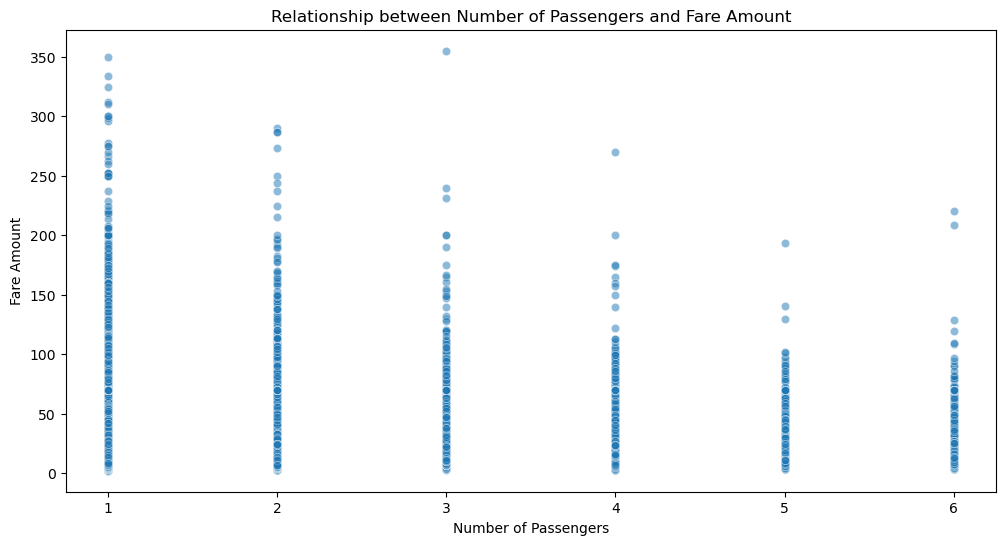

Correlation between Number of Passengers and Fare Amount: 0.04


In [53]:
# Show relationship between fare and number of passengers
# Plot the relationship between fare_amount and passenger_count
render_scatter_plot('passenger_count', 'fare_amount', df_nonzero, 'Relationship between Number of Passengers and Fare Amount', 'Number of Passengers', 'Fare Amount')

# Calculate the correlation value between passenger_count and fare_amount
correlation_value_passenger_fare = df_nonzero['passenger_count'].corr(df_nonzero['fare_amount'])
print(f'Correlation between Number of Passengers and Fare Amount: {correlation_value_passenger_fare:.2f}')


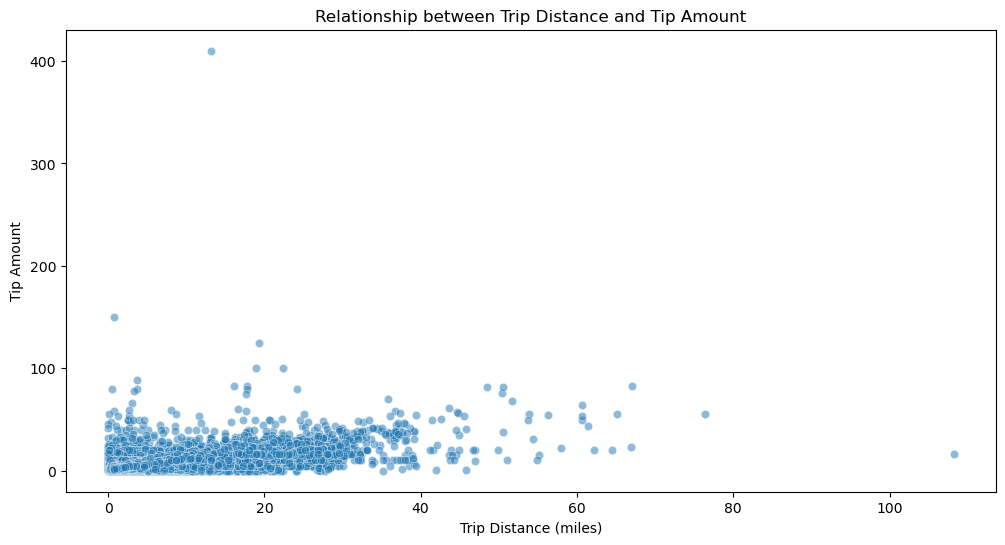

Correlation between Trip Distance and Tip Amount: 0.79


In [54]:
# Show relationship between tip and trip distance

# Plot the relationship between tip_amount and trip_distance
render_scatter_plot('trip_distance', 'tip_amount', df_nonzero, 'Relationship between Trip Distance and Tip Amount', 'Trip Distance (miles)', 'Tip Amount')

# Calculate the correlation value between trip_distance and tip_amount
correlation_value_tip_distance = df_nonzero['trip_distance'].corr(df_nonzero['tip_amount'])
print(f'Correlation between Trip Distance and Tip Amount: {correlation_value_tip_distance:.2f}')

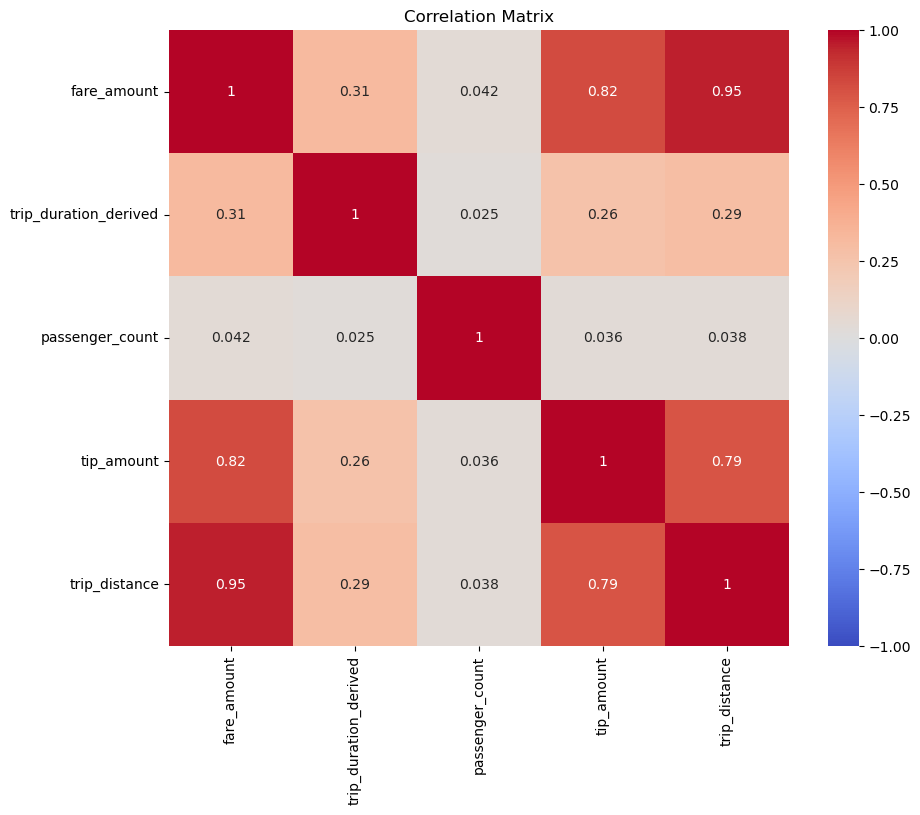

In [55]:
correlation_columns = ['fare_amount', 'trip_duration_derived', 'passenger_count', 'tip_amount', 'trip_distance']

# Calculate the correlation matrix
correlation_matrix = df_nonzero[correlation_columns].corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

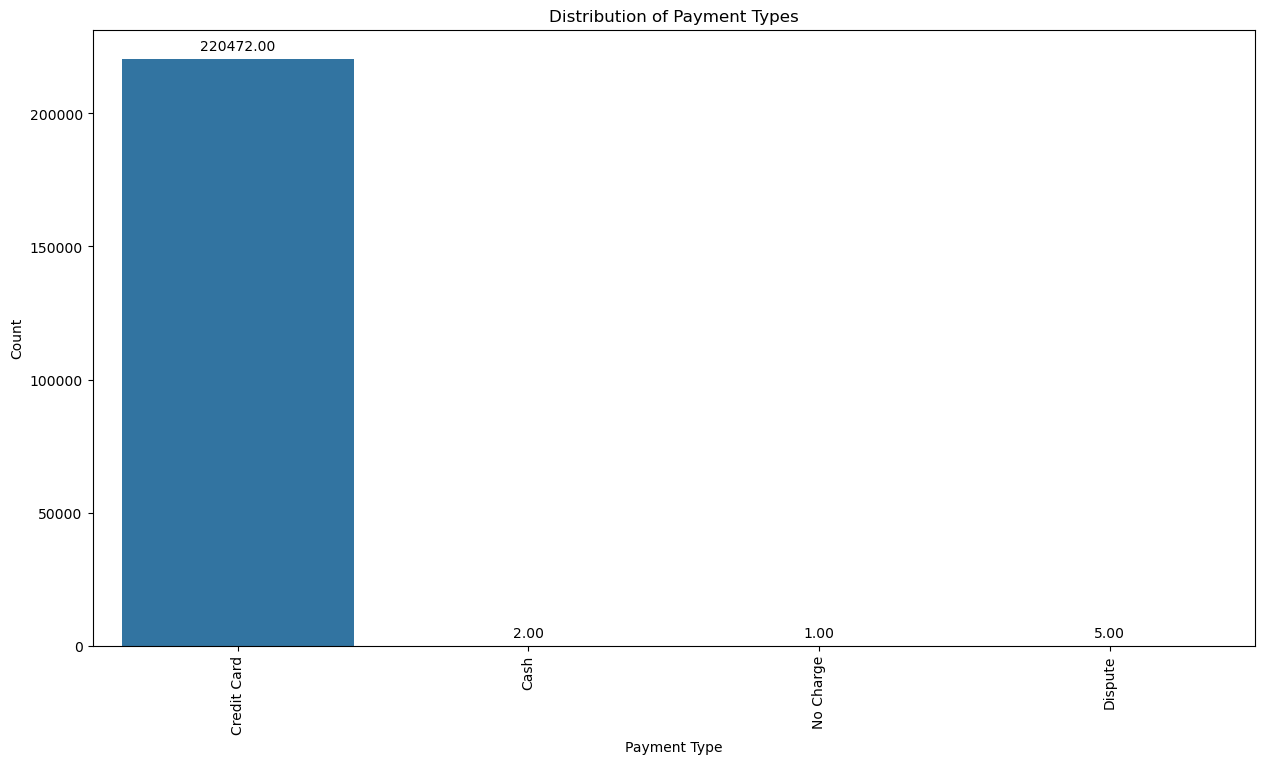

In [56]:
# Analyse the distribution of different payment types (payment_type).

# Get the count of each payment type
payment_type_counts = df_nonzero['payment_type'].value_counts()

# Map the payment type codes to their corresponding descriptions
payment_type_map = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided Trip'
}

# Replace the payment type codes with descriptions
payment_type_counts.index = payment_type_counts.index.map(payment_type_map)

# Plot the distribution of payment types
show_bar_plot(payment_type_counts.index, payment_type_counts.values, 'Distribution of Payment Types', 'Payment Type', 'Count', show_data_labels=True)


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *data/taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [57]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [58]:
import geopandas as gpd
from pathlib import Path

base_dir = Path.cwd().parent.parent
# You construct the path by simply dividing (/) the folders. 
# Pathlib will automatically convert the slashes to whatever OS is running it!
shapefile_path = base_dir / 'data' / 'taxi_zones' / 'taxi_zones.shp'


# Read the shapefile using geopandas
zones = gpd.read_file(shapefile_path)
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


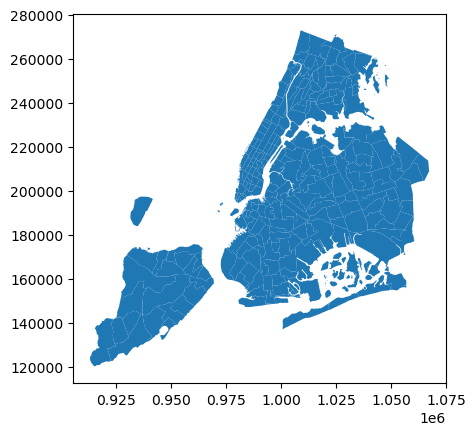

In [59]:
print(zones.info())
zones.plot();

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [60]:
# Merge zones and trip records using locationID and PULocationID
# Use the lowercase 'pulocationid' because we standardized the column names earlier!
merged_df = df_nonzero.merge(zones, left_on='pulocationid', right_on='LocationID', how='left')
# Display the first few rows of the merged DataFrame
merged_df.head()


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,...,pickup_day,pickup_month,trip_duration_derived,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,2023-06-14 12:32:12,2023-06-14 12:43:29,1,2.10,1,43,42,1,13.5,...,Wednesday,June,11.283333,43.0,0.099739,0.000380,Central Park,43.0,Manhattan,"POLYGON ((991852.973 217950.807, 991725.244 21..."
1,2,2023-04-27 21:31:05,2023-04-27 21:40:34,1,1.50,1,48,229,1,10.7,...,Thursday,April,9.483333,48.0,0.043747,0.000094,Clinton East,48.0,Manhattan,"POLYGON ((986694.313 214463.846, 986568.184 21..."
2,2,2023-11-02 18:28:42,2023-11-02 18:41:04,2,1.62,1,170,237,1,12.8,...,Thursday,November,12.366667,170.0,0.045769,0.000074,Murray Hill,170.0,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21..."
3,2,2023-01-18 11:29:17,2023-01-18 11:37:59,1,1.33,1,161,236,1,10.0,...,Wednesday,January,8.700000,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
4,2,2023-09-02 19:14:37,2023-09-02 19:25:56,1,1.01,1,161,230,1,11.4,...,Saturday,September,11.316667,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [61]:
# Group data by location and calculate the number of trips

trips_per_location = merged_df.groupby('pulocationid').size().reset_index(name='total_trips')

# Display the first few rows of the result
trips_per_location.head()

,pulocationid,total_trips
0,1,9
1,4,233
2,7,36
3,10,58
4,12,81


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

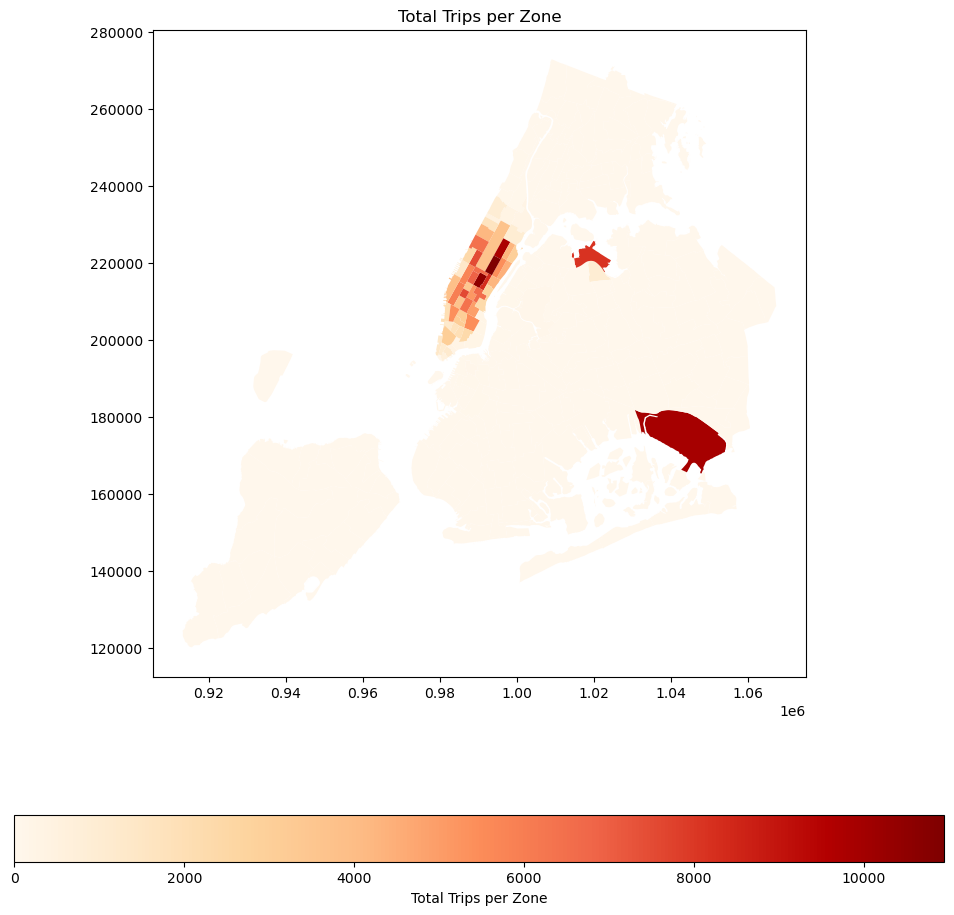

In [62]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(trips_per_location, left_on='LocationID', right_on='pulocationid', how='left')

# Fill NaN values with 0 (for zones with no trips)
zones_with_trips['total_trips'].fillna(0, inplace=True)

# Plot the map of zones showing total trips per zone
zones_with_trips.plot(column='total_trips', cmap='OrRd', legend=True, legend_kwds={'label': "Total Trips per Zone", 'orientation': "horizontal"}, figsize=(12, 12))
plt.title('Total Trips per Zone')
plt.show()



The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

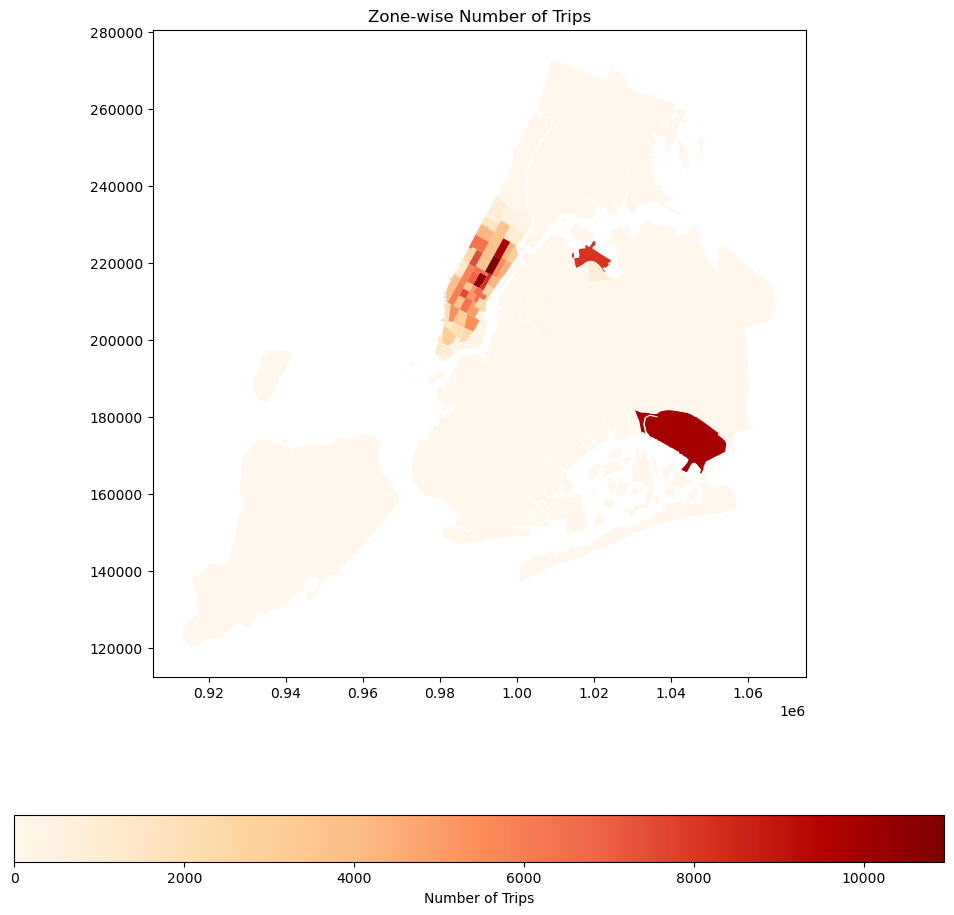

In [63]:
# Define figure and axis


# Plot the map and display it
# Assuming df contains the trip data and zones is a GeoDataFrame with zone geometries

# Aggregate the number of trips per zone using PULocationID
zone_trip_counts = merged_df['pulocationid'].value_counts().reset_index()
zone_trip_counts.columns = ['LocationID', 'trip_count']

# Merge the trip counts with the GeoDataFrame
zones = zones.merge(zone_trip_counts, on='LocationID', how='left')

# Fill NaN values with 0 (if there are zones with no trips)
zones['trip_count'] = zones['trip_count'].fillna(0)

# Define the figure and axis for the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the GeoDataFrame with the trip counts
zones.plot(column='trip_count', ax=ax, legend=True, legend_kwds={'label': "Number of Trips", 'orientation': "horizontal"}, cmap='OrRd')

# Display the plot
plt.title('Zone-wise Number of Trips')
plt.show()


In [64]:
# can you try displaying the zones DF sorted by the number of trips?


# Sort the zones by the number of trips
zones_sorted = zones.sort_values(by='trip_count', ascending=False)

# Display the sorted zones
zones_sorted[['zone', 'trip_count']]

,zone,trip_count
236,Upper East Side South,10949.0
160,Midtown Center,10506.0
131,JFK Airport,9919.0
235,Upper East Side North,9788.0
161,Midtown East,8260.0
...,...,...
155,Mariners Harbor,0.0
153,Marine Park/Floyd Bennett Field,0.0
152,Marble Hill,0.0
149,Manhattan Beach,0.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

,pulocationid,dolocationid,pickup_hour,trip_duration_derived,trip_distance,speed
612972,163,264,12,88.283333,0.030,0.020389
321866,90,261,2,13.516667,0.010,0.044390
152348,48,162,20,1388.116667,1.410,0.060946
858194,229,161,2,1414.716667,1.590,0.067434
859968,229,236,0,1433.950000,2.170,0.090798
785583,211,232,15,699.250000,1.310,0.112406
864088,230,148,16,1397.300000,3.490,0.149860
513909,141,264,21,1403.016667,3.530,0.150960
433052,125,249,20,289.060000,0.736,0.152771
517235,142,144,11,1438.150000,3.720,0.155199


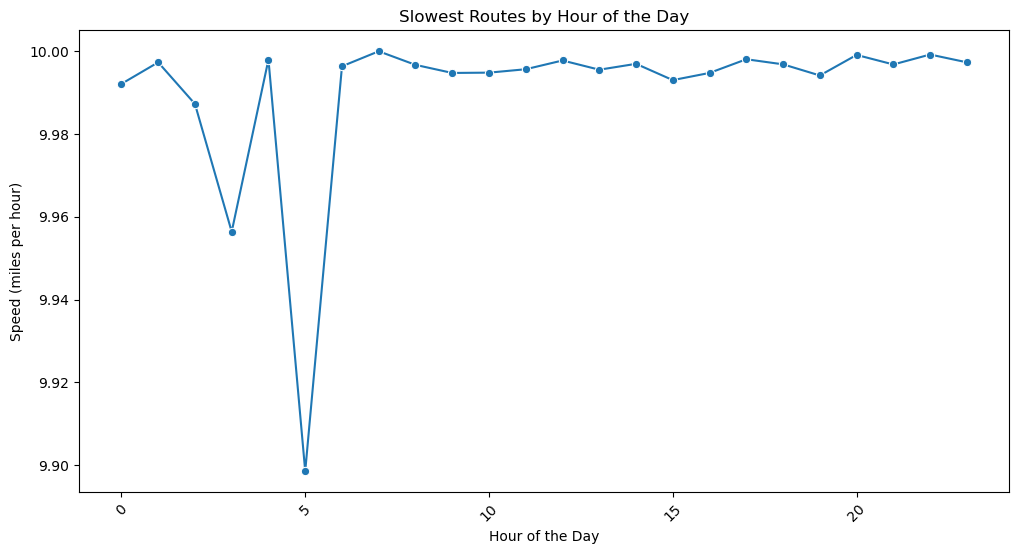

In [65]:
# Find routes which have the slowest speeds at different times of the day
def render_line_plot(x, y, title, xlabel, ylabel, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.lineplot(x=x, y=y, marker='o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

# # We extract the hour from the datetime column
# merged_df['pickup_hour'] = merged_df['tpep_pickup_datetime'].dt.hour

# We calculate duration in MINUTES (since your formula divides by 60)
merged_df['trip_duration_derived'] = (merged_df['tpep_dropoff_datetime'] - merged_df['tpep_pickup_datetime']).dt.total_seconds() / 60

# 2. Now run your grouping code! (Notice I swapped in 'pickup_hour' here)
grouped = merged_df.groupby(['pulocationid', 'dolocationid', 'pickup_hour'])

# Calculate the average trip duration and distance for each group
route_stats = grouped.agg({
    'trip_duration_derived': 'mean',
    'trip_distance': 'mean'
}).reset_index()

# Safety filter: Drop any rows where average duration is 0 to avoid breaking math
route_stats = route_stats[route_stats['trip_duration_derived'] > 0]

# Calculate the speed for each route and hour
route_stats['speed'] = route_stats['trip_distance'] / (route_stats['trip_duration_derived'] / 60)

# Identify slow routes and sort them to find the absolute slowest
slow_routes = route_stats[route_stats['speed'] < 10]
slow_routes = slow_routes.sort_values(by='speed', ascending=True)

# Display the slow routes
display(slow_routes.head(10))

# Find routes which have the slowest speeds at different times of the day
slow_routes_by_hour = slow_routes.groupby('pickup_hour').apply(lambda x: x.nlargest(1, 'speed')).reset_index(drop=True)
render_line_plot(slow_routes_by_hour.pickup_hour, slow_routes_by_hour.speed, 'Slowest Routes by Hour of the Day', 'Hour of the Day', 'Speed (miles per hour)')

How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

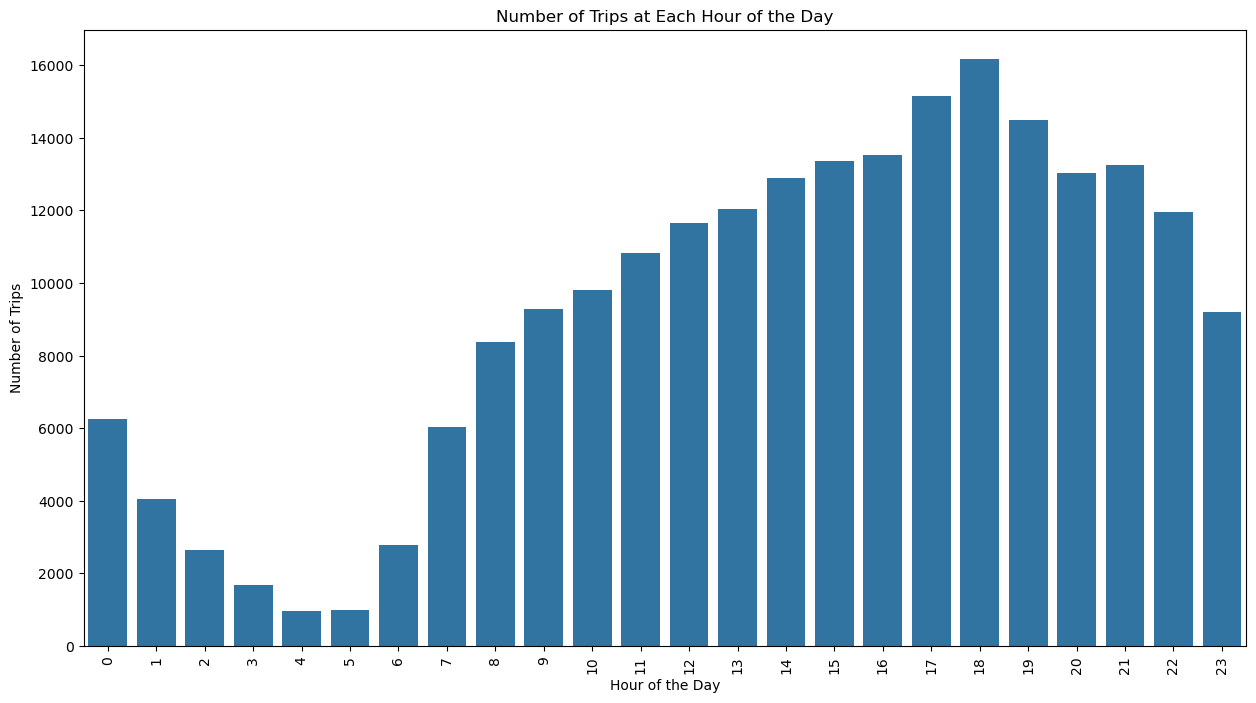

The busiest hour is 18:00 with 16166 trips.


In [66]:
# Visualise the number of trips per hour and find the busiest hour

# Calculate the number of trips for each hour of the day
hourly_trip_counts = merged_df['pickup_hour'].value_counts().sort_index()

# Plot the number of trips for each hour of the day
show_bar_plot(hourly_trip_counts.index, hourly_trip_counts.values, 'Number of Trips at Each Hour of the Day', 'Hour of the Day', 'Number of Trips')

# Find the busiest hour and show the number of trips for that hour
busiest_hour = hourly_trip_counts.idxmax()
busiest_hour_trips = hourly_trip_counts.max()
print(f'The busiest hour is {busiest_hour}:00 with {busiest_hour_trips} trips.')



In [67]:
busiest_hours = hourly_trip_counts.nlargest(5)

# Display the actual number of trips in the five busiest hours
print("Actual number of trips in the five busiest hours:")
busiest_hours

Actual number of trips in the five busiest hours:


pickup_hour
18    16166
17    15152
19    14486
16    13518
15    13361
Name: count, dtype: int64

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [68]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 30
scaled_trips_per_location = trips_per_location.copy()
scaled_trips_per_location['total_trips'] *= sample_fraction

# Display the scaled-up number of trips
scaled_trips_per_location.head()


,pulocationid,total_trips
0,1,270
1,4,6990
2,7,1080
3,10,1740
4,12,2430


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

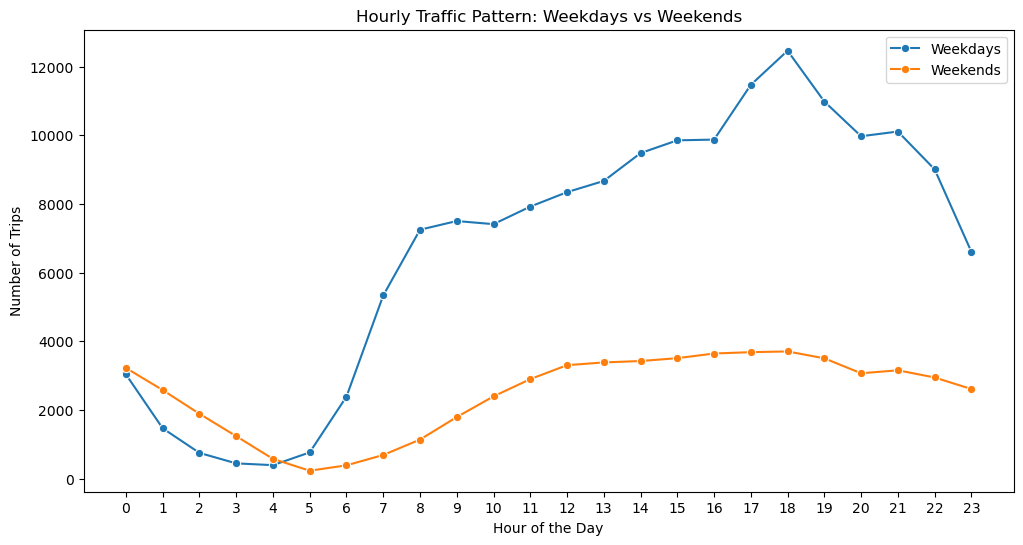

In [69]:
# Compare traffic trends for the week days and weekends
# Separate the data into weekdays and weekends
merged_df['pickup_day_derived'] = merged_df['tpep_pickup_datetime'].dt.dayofweek

weekdays_df = merged_df[merged_df['pickup_day_derived'] < 5]  # Monday to Friday
weekends_df = merged_df[merged_df['pickup_day_derived'] >= 5]  # Saturday and Sunday

# Calculate the number of trips for each hour of the day for weekdays
weekday_hourly_pickups = weekdays_df['pickup_hour'].value_counts().sort_index()

# Calculate the number of trips for each hour of the day for weekends
weekend_hourly_pickups = weekends_df['pickup_hour'].value_counts().sort_index()

# Plot the hourly traffic pattern for weekdays
plt.figure(figsize=(12, 6))
sns.lineplot(x=weekday_hourly_pickups.index, y=weekday_hourly_pickups.values, marker='o', label='Weekdays')
sns.lineplot(x=weekend_hourly_pickups.index, y=weekend_hourly_pickups.values, marker='o', label='Weekends')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Traffic Pattern: Weekdays vs Weekends')
plt.xticks(range(24))
plt.legend()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

Looking at the charts, a few clear trends jump out:
* **The Rush Hour Spike:** Taxi rides peak heavily between 5 PM and 7 PM. This makes perfect sense, as it’s the exact window when people are leaving the office and heading home or going out to dinner. 
* **The Dead Zone:** The city really does sleep a little bit. Things get incredibly quiet between 2 AM and 5 AM.
* **Weekdays vs. Weekends:** Weekdays have very sharp, distinct spikes for the morning and evening commutes. Weekends, on the other hand, don't have those sharp commute spikes; instead, the rides are spread out much more evenly across the afternoon and stay busier much later into the night.
* **Seasonal Bumps:** Certain months, like May and October, seem to bring in more revenue. This is likely because the weather is comfortable, encouraging people to go out, whereas late summer (when many locals leave for vacation) or the dead of winter might see dips.

**Why does knowing this actually matter?**

If you were managing a taxi fleet, this data is exactly what you need to run a profitable business. Instead of just guessing, you can use these patterns to actually manage your drivers. You'd know exactly when to push to have all your cars on the road to meet high demand, and when to let drivers go home to rest so they aren't wasting gas driving around empty streets at 3 AM. 

It also lets you play with dynamic pricing. If you know exactly when the 6 PM rush is hitting, you can implement surge pricing to maximize your revenue. Conversely, if you know the fleet is sitting idle at 11 AM on a Tuesday, you could offer promo codes or cheaper rates to encourage people to take a cab instead of the subway. Basically, it takes the guesswork out of the business!


**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

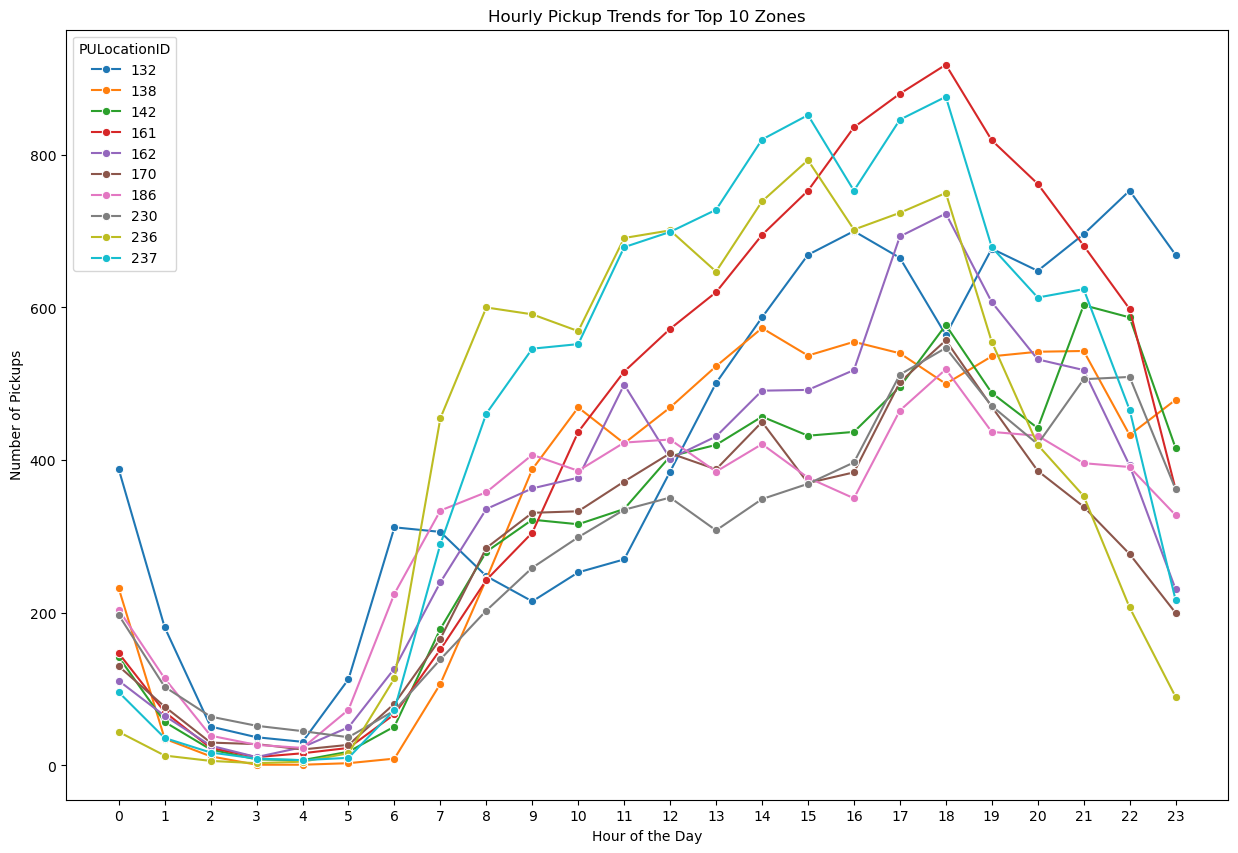

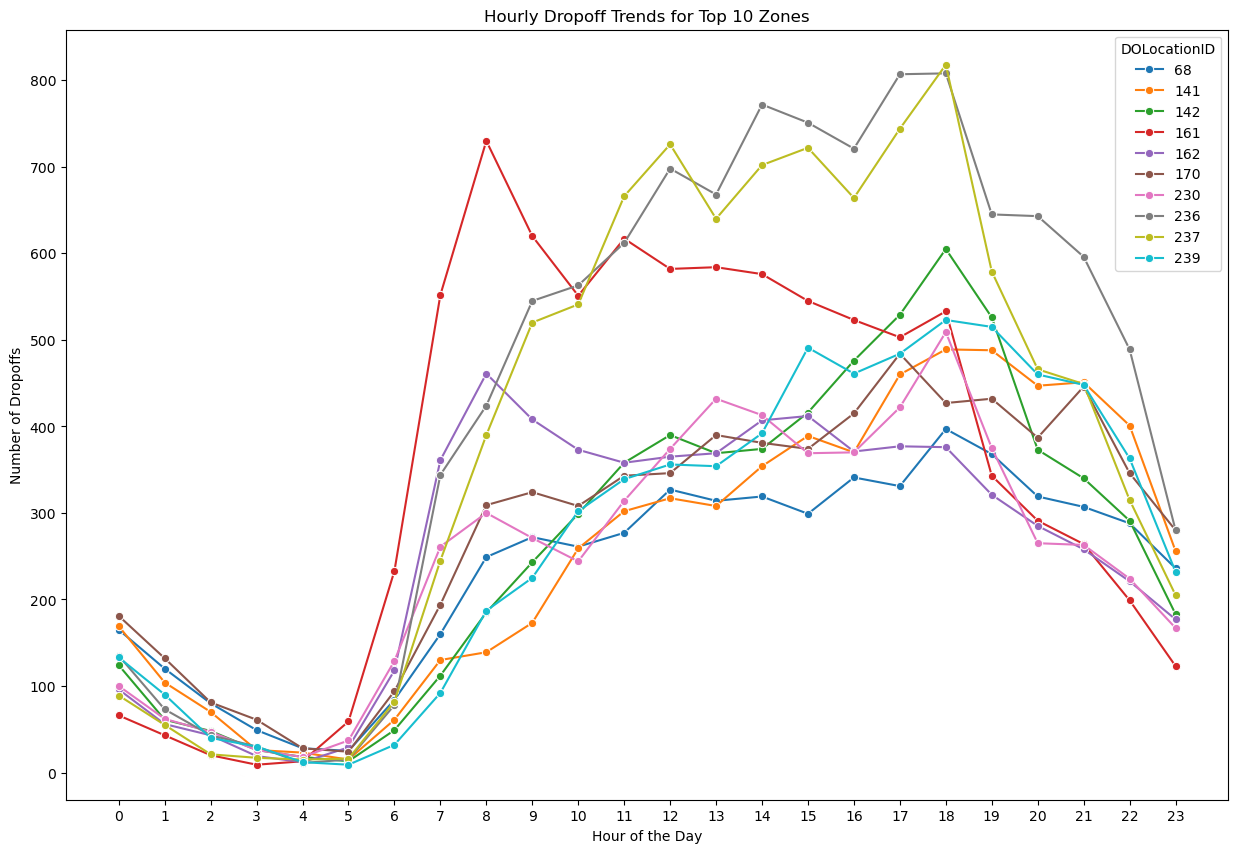

In [70]:
# Find top 10 pickup and dropoff zones

# Group by PULocationID and hour of the day to find the number of pickups
pickup_counts = merged_df.groupby(['pulocationid', 'pickup_hour']).size().reset_index(name='pickup_count')

# Find the top 10 zones with the highest number of hourly pickups
top_pickup_zones = pickup_counts.groupby('pulocationid')['pickup_count'].sum().nlargest(10).index

# Filter the data to include only the top 10 pickup zones
top_pickup_data = pickup_counts[pickup_counts['pulocationid'].isin(top_pickup_zones)].copy()

# FIX: Convert the IDs to strings so Seaborn treats them as distinct categories
top_pickup_data['pulocationid'] = top_pickup_data['pulocationid'].astype(str)

# Plot the hourly pickup trends for the top 10 zones
plt.figure(figsize=(15, 10))
# FIX: Added palette='tab10' for 10 distinct bright colors
sns.lineplot(data=top_pickup_data, x='pickup_hour', y='pickup_count', hue='pulocationid', marker='o', palette='tab10')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Pickups')
plt.title('Hourly Pickup Trends for Top 10 Zones')
plt.legend(title='PULocationID')
plt.xticks(range(24))
plt.show()

# Group by DOLocationID and hour of the day to find the number of dropoffs
dropoff_counts = merged_df.groupby(['dolocationid', 'pickup_hour']).size().reset_index(name='dropoff_count')

# Find the top 10 zones with the highest number of hourly dropoffs
top_dropoff_zones = dropoff_counts.groupby('dolocationid')['dropoff_count'].sum().nlargest(10).index

# Filter the data to include only the top 10 dropoff zones
top_dropoff_data = dropoff_counts[dropoff_counts['dolocationid'].isin(top_dropoff_zones)].copy()

top_dropoff_data['dolocationid'] = top_dropoff_data['dolocationid'].astype(str)

# Plot the hourly dropoff trends for the top 10 zones
plt.figure(figsize=(15, 10))
# FIX: Added palette='tab10'
sns.lineplot(data=top_dropoff_data, x='pickup_hour', y='dropoff_count', hue='dolocationid', marker='o', palette='tab10')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Dropoffs')
plt.title('Hourly Dropoff Trends for Top 10 Zones')
plt.legend(title='DOLocationID')
plt.xticks(range(24))
plt.show()


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [71]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Calculate the number of pickups for each zone
pickup_counts = merged_df['pulocationid'].value_counts().reset_index()
pickup_counts.columns = ['LocationID', 'pickup_count']

# Calculate the number of dropoffs for each zone
dropoff_counts = merged_df['dolocationid'].value_counts().reset_index()
dropoff_counts.columns = ['LocationID', 'dropoff_count']

# Merge the pickup and dropoff counts
pickup_dropoff_counts = pickup_counts.merge(dropoff_counts, on='LocationID', how='outer').fillna(0)

# Calculate the ratio of pickups to dropoffs
pickup_dropoff_counts['pickup_dropoff_ratio'] = pickup_dropoff_counts['pickup_count'] / pickup_dropoff_counts['dropoff_count']

# Display the 10 highest pickup/dropoff ratios
highest_ratios = pickup_dropoff_counts.nlargest(10, 'pickup_dropoff_ratio')
print("10 Highest Pickup/Dropoff Ratios:")
print(highest_ratios[['LocationID', 'pickup_dropoff_ratio']])

# Display the 10 lowest pickup/dropoff ratios
lowest_ratios = pickup_dropoff_counts.nsmallest(10, 'pickup_dropoff_ratio')
print("\n10 Lowest Pickup/Dropoff Ratios:")
print(lowest_ratios[['LocationID', 'pickup_dropoff_ratio']])

10 Highest Pickup/Dropoff Ratios:
     LocationID  pickup_dropoff_ratio
67           70             14.671642
125         132              4.630719
131         138              2.951846
179         186              1.620675
107         114              1.399463
40           43              1.368323
241         249              1.338929
207         215              1.333333
155         162              1.316754
97          100              1.260239

10 Lowest Pickup/Dropoff Ratios:
    LocationID  pickup_dropoff_ratio
1            3                   0.0
3            5                   0.0
4            6                   0.0
6            8                   0.0
7            9                   0.0
9           11                   0.0
13          15                   0.0
14          16                   0.0
16          18                   0.0
17          19                   0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [72]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Filter the data for trips during night hours (11 PM to 5 AM)
night_hours_df = merged_df[(merged_df['pickup_hour'] >= 23) | (merged_df['pickup_hour'] <= 5)]

# Group by PULocationID to find the number of pickups during night hours
night_pickup_counts = night_hours_df['pulocationid'].value_counts().reset_index()
night_pickup_counts.columns = ['LocationID', 'pickup_count']

# Group by DOLocationID to find the number of dropoffs during night hours
night_dropoff_counts = night_hours_df['dolocationid'].value_counts().reset_index()
night_dropoff_counts.columns = ['LocationID', 'dropoff_count']

# Find the top 10 pickup zones during night hours
top_night_pickup_zones = night_pickup_counts.nlargest(10, 'pickup_count')

# Find the top 10 dropoff zones during night hours
top_night_dropoff_zones = night_dropoff_counts.nlargest(10, 'dropoff_count')

# Display the top 10 pickup and dropoff zones during night hours
print("Top 10 Pickup Zones during Night Hours (11 PM to 5 AM):")
print(top_night_pickup_zones)

print("\nTop 10 Dropoff Zones during Night Hours (11 PM to 5 AM):")
print(top_night_dropoff_zones)


Top 10 Pickup Zones during Night Hours (11 PM to 5 AM):
   LocationID  pickup_count
0          79          1986
1         249          1678
2         132          1470
3          48          1231
4         148          1227
5         114          1172
6         230           860
7         186           808
8         138           763
9          68           752

Top 10 Dropoff Zones during Night Hours (11 PM to 5 AM):
  LocationID  dropoff_count
0         79           1077
1         48            807
2        170            787
3        107            756
4        263            710
5         68            703
6        141            663
7        249            655
8        236            587
9         90            584


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

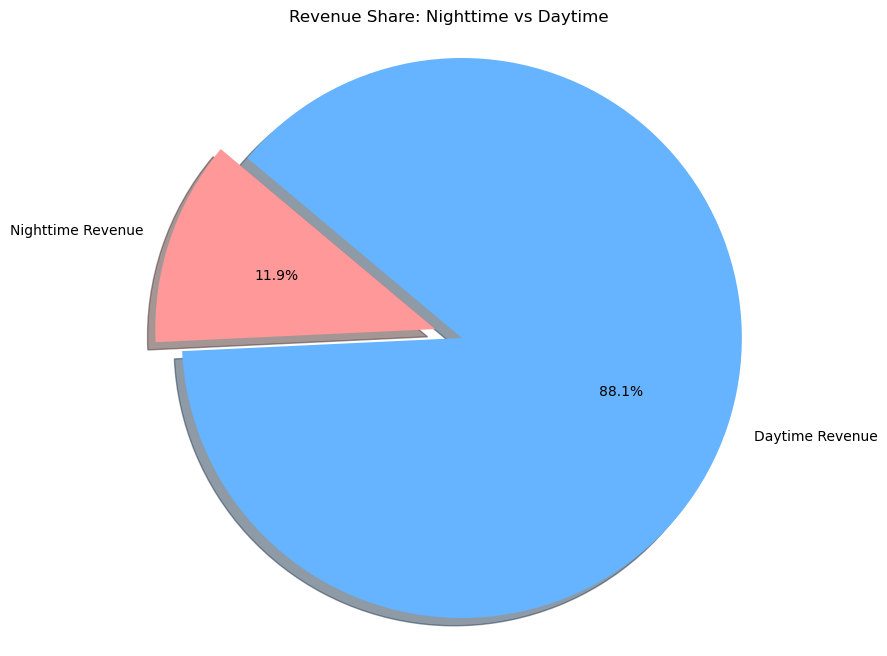

In [73]:
# Filter for night hours (11 PM to 5 AM)
night_hours_df = merged_df[(merged_df['pickup_hour'] >= 23) | (merged_df['pickup_hour'] <= 5)]

# Calculate total revenue for night hours
night_revenue = night_hours_df['total_amount'].sum()

# Filter for day hours (6 AM to 10 PM)
day_hours_df = merged_df[(merged_df['pickup_hour'] >= 6) & (merged_df['pickup_hour'] <= 22)]

# Calculate total revenue for day hours
day_revenue = day_hours_df['total_amount'].sum()

# Calculate the total revenue
total_revenue = merged_df['total_amount'].sum()

# Calculate the revenue share for night and day hours
night_revenue_share = (night_revenue / total_revenue) * 100
day_revenue_share = (day_revenue / total_revenue) * 100

# Visualize the revenue share using a pie chart
labels = ['Nighttime Revenue', 'Daytime Revenue']
sizes = [night_revenue_share, day_revenue_share]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode the 1st slice (Nighttime Revenue)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Revenue Share: Nighttime vs Daytime')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [74]:
# Analyse the fare per mile per passenger for different passenger counts

# Calculate the fare per mile for each trip
merged_df['fare_per_mile_derived'] = merged_df['fare_amount'] / merged_df['trip_distance']

# Group by passenger count and calculate the average fare per mile
avg_fare_per_mile = merged_df.groupby('passenger_count')['fare_per_mile_derived'].mean().reset_index()

# Calculate the average fare per mile per passenger
avg_fare_per_mile['fare_per_mile_per_passenger'] = avg_fare_per_mile['fare_per_mile_derived'] / avg_fare_per_mile['passenger_count']

# Display the results
avg_fare_per_mile




,passenger_count,fare_per_mile_derived,fare_per_mile_per_passenger
0,1,8.924392,8.924392
1,2,10.124354,5.062177
2,3,9.157037,3.052346
3,4,22.531874,5.632969
4,5,7.883415,1.576683
5,6,7.587388,1.264565


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

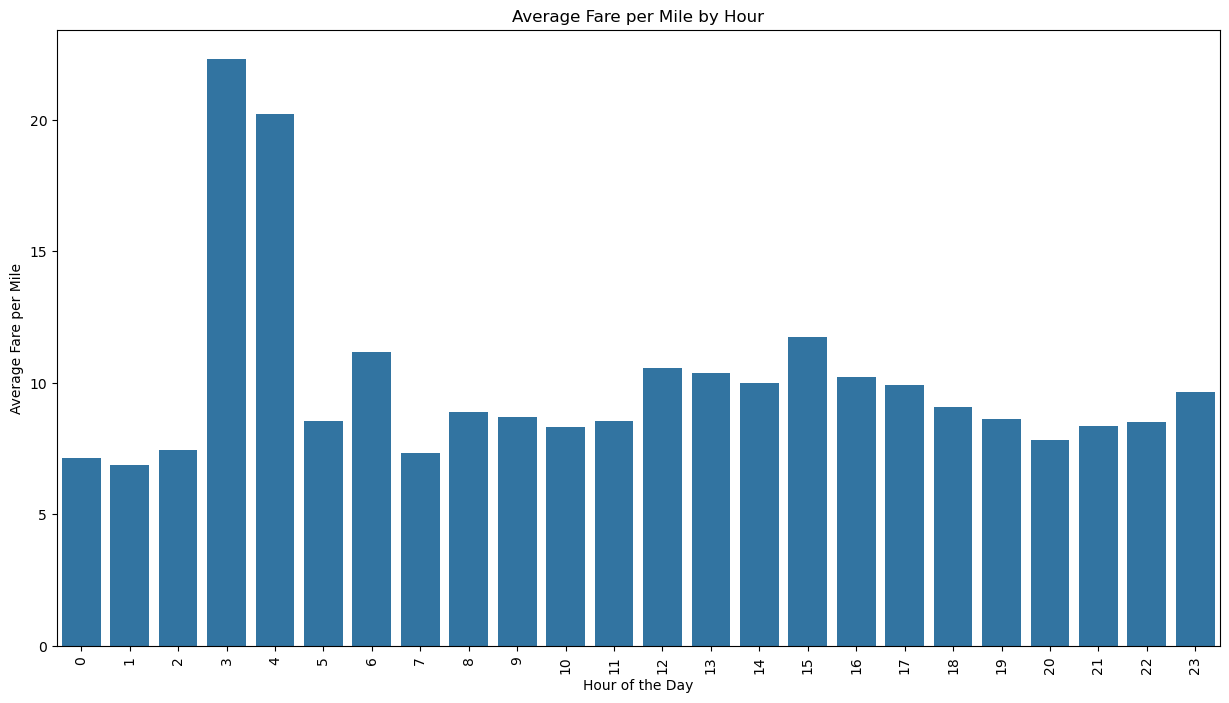

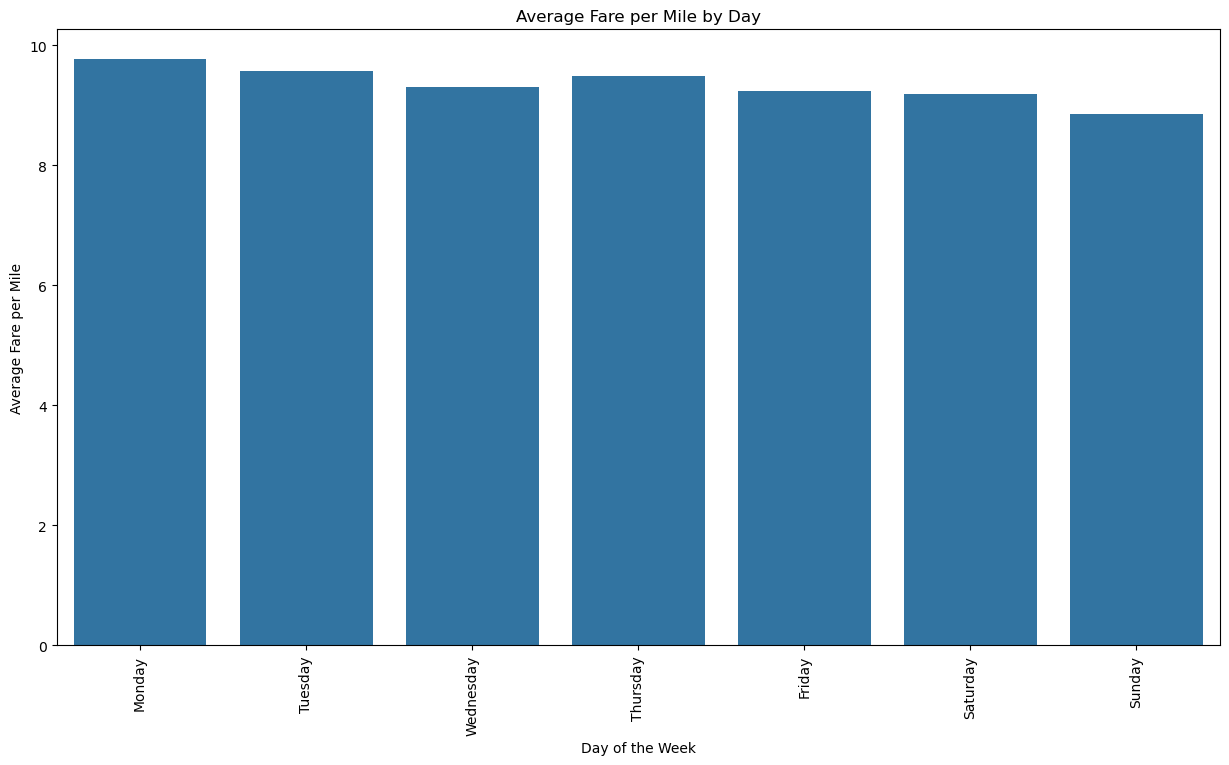

In [75]:
# Compare the average fare per mile for different days and for different times of the day
# Compare the average fare per mile for different days and different times of the day

# Group by hour of the day and calculate average fare per mile
avg_fare_per_mile_by_hour = (
    merged_df.groupby('pickup_hour')['fare_per_mile_derived']
    .mean()
    .reset_index()
)

# Group by day number and calculate average fare per mile
avg_fare_per_mile_by_day = (
    merged_df.groupby('pickup_day_num')['fare_per_mile_derived']
    .mean()
    .reset_index()
)

# Mapping day numbers to day names
day_name_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

# Create readable day name column
avg_fare_per_mile_by_day['pickup_day_name'] = (
    avg_fare_per_mile_by_day['pickup_day_num']
    .map(day_name_map)
)

# Plot average fare per mile by hour
show_bar_plot(
    avg_fare_per_mile_by_hour['pickup_hour'],
    avg_fare_per_mile_by_hour['fare_per_mile_derived'],
    'Average Fare per Mile by Hour',
    'Hour of the Day',
    'Average Fare per Mile'
)

# Plot average fare per mile by day
show_bar_plot(
    avg_fare_per_mile_by_day['pickup_day_name'],
    avg_fare_per_mile_by_day['fare_per_mile_derived'],
    'Average Fare per Mile by Day',
    'Day of the Week',
    'Average Fare per Mile'
)

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

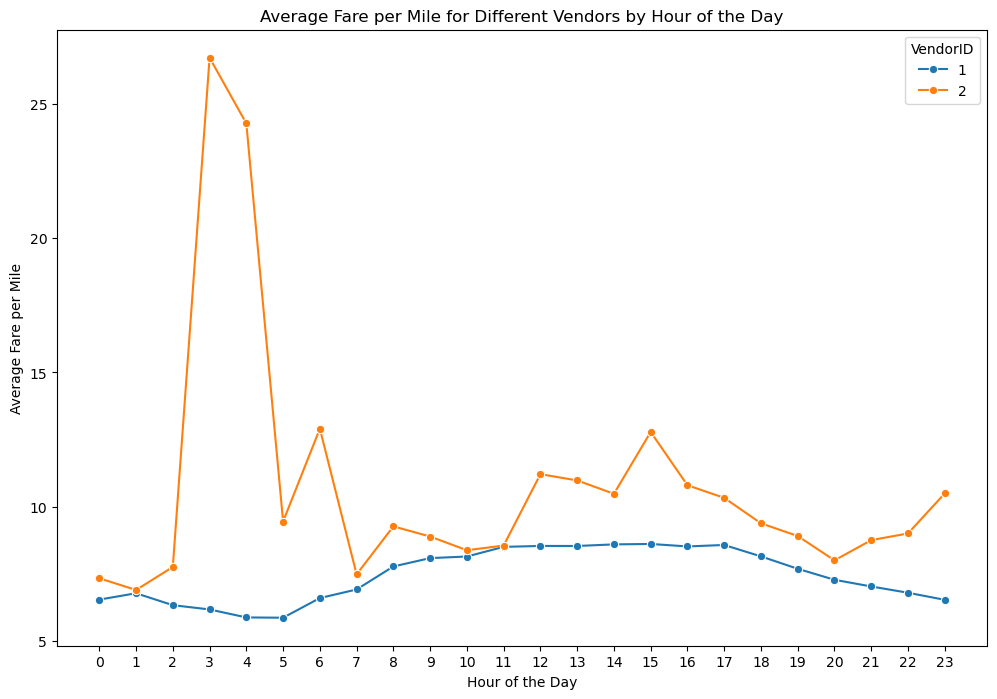

In [88]:
# Compare fare per mile for different vendors


# Group by VendorID and hour of the day to calculate the average fare per mile
avg_fare_per_mile_by_vendor_hour = merged_df.groupby(['vendorid', 'pickup_hour'])['fare_per_mile_derived'].mean().reset_index()

# Plot the average fare per mile for different vendors for different hours of the day
plt.figure(figsize=(12, 8))
sns.lineplot(x='pickup_hour', y='fare_per_mile_derived', hue='vendorid', data=avg_fare_per_mile_by_vendor_hour, marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Fare per Mile')
plt.title('Average Fare per Mile for Different Vendors by Hour of the Day')
plt.xticks(range(24))
plt.legend(title='VendorID')
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [77]:
# Defining distance tiers

distance_tiers = [
    (0, 2),
    (2, 5),
    (5, float('inf'))
]

# Initialize a list to store the results
results = []

# Loop through each distance tier
for min_distance, max_distance in distance_tiers:
    # Filter the data for the current distance tier
    tier_df = merged_df[(merged_df['trip_distance'] > min_distance) & (merged_df['trip_distance'] <= max_distance)]
    
    # Group by vendorid and calculate the average fare per mile
    avg_fare_per_mile = tier_df.groupby('vendorid').apply(lambda x: (x['fare_amount'] / x['trip_distance']).mean()).reset_index()
    avg_fare_per_mile.columns = ['vendorid', 'avg_fare_per_mile']
    
    # Add the distance tier information
    avg_fare_per_mile['distance_tier'] = f'{min_distance} - {max_distance} miles'
    
    # Append the results to the list
    results.append(avg_fare_per_mile)

# Concatenate the results into a single DataFrame
fare_rate_comparison = pd.concat(results, ignore_index=True)

# Display the results
fare_rate_comparison


,vendorid,avg_fare_per_mile,distance_tier
0,1,9.415378,0 - 2 miles
1,2,13.223522,0 - 2 miles
2,1,6.364670,2 - 5 miles
3,2,6.549700,2 - 5 miles
4,1,4.479490,5 - inf miles
5,2,4.501442,5 - inf miles


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

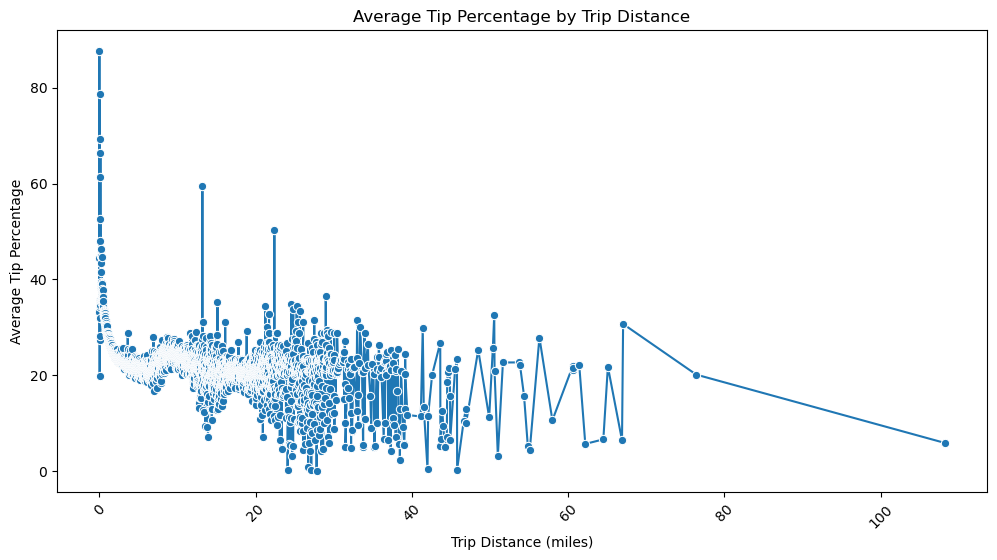

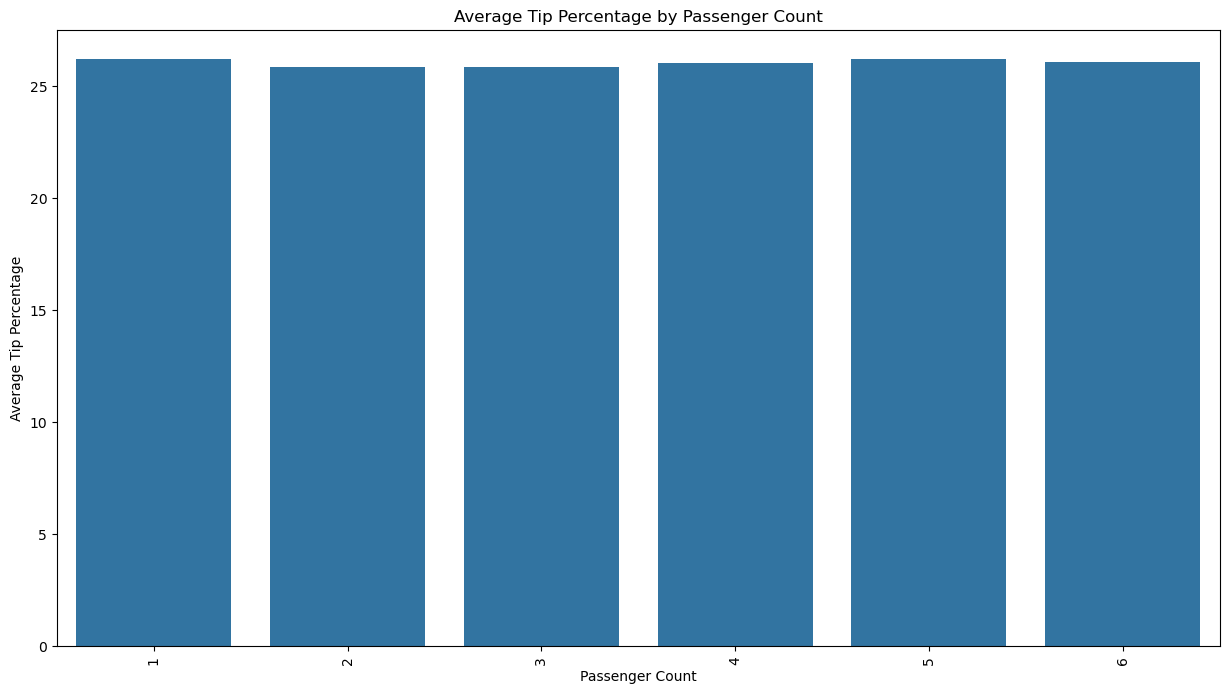

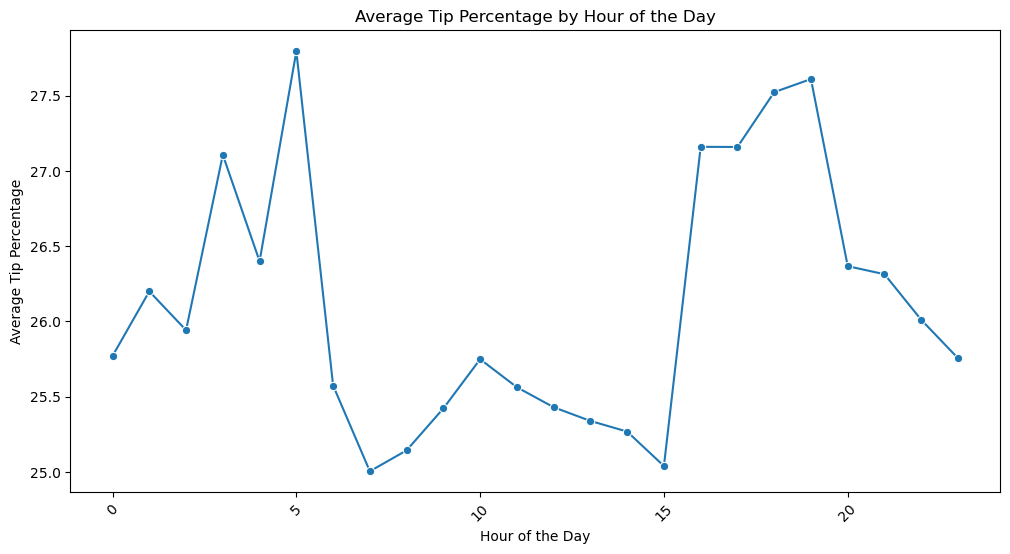

In [78]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

# Calculate the tip percentage for each trip
merged_df['tip_percentage_derived'] = (merged_df['tip_amount'] / merged_df['fare_amount']) * 100

# Group by trip distance and calculate the average tip percentage
avg_tip_by_distance = merged_df.groupby('trip_distance')['tip_percentage_derived'].mean().reset_index()

# Group by passenger count and calculate the average tip percentage
avg_tip_by_passenger_count = merged_df.groupby('passenger_count')['tip_percentage_derived'].mean().reset_index()

# Group by hour of the day and calculate the average tip percentage
avg_tip_by_hour = merged_df.groupby('pickup_hour')['tip_percentage_derived'].mean().reset_index()

# Plot the average tip percentage by trip distance
render_line_plot(avg_tip_by_distance['trip_distance'], avg_tip_by_distance['tip_percentage_derived'], 'Average Tip Percentage by Trip Distance', 'Trip Distance (miles)', 'Average Tip Percentage')

# Plot the average tip percentage by passenger count
show_bar_plot(avg_tip_by_passenger_count['passenger_count'], avg_tip_by_passenger_count['tip_percentage_derived'], 'Average Tip Percentage by Passenger Count', 'Passenger Count', 'Average Tip Percentage')

# Plot the average tip percentage by hour of the day
render_line_plot(avg_tip_by_hour['pickup_hour'], avg_tip_by_hour['tip_percentage_derived'], 'Average Tip Percentage by Hour of the Day', 'Hour of the Day', 'Average Tip Percentage')


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [79]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

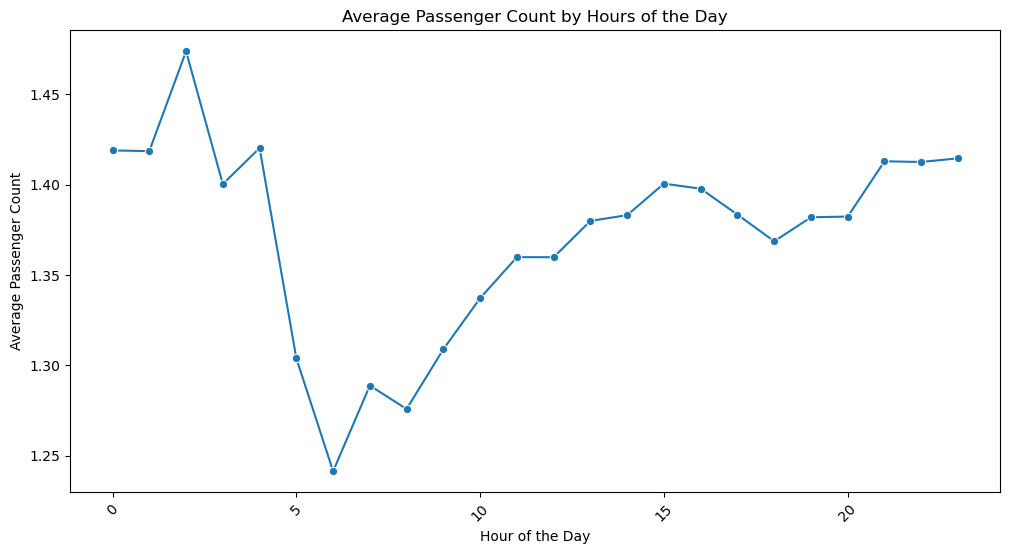

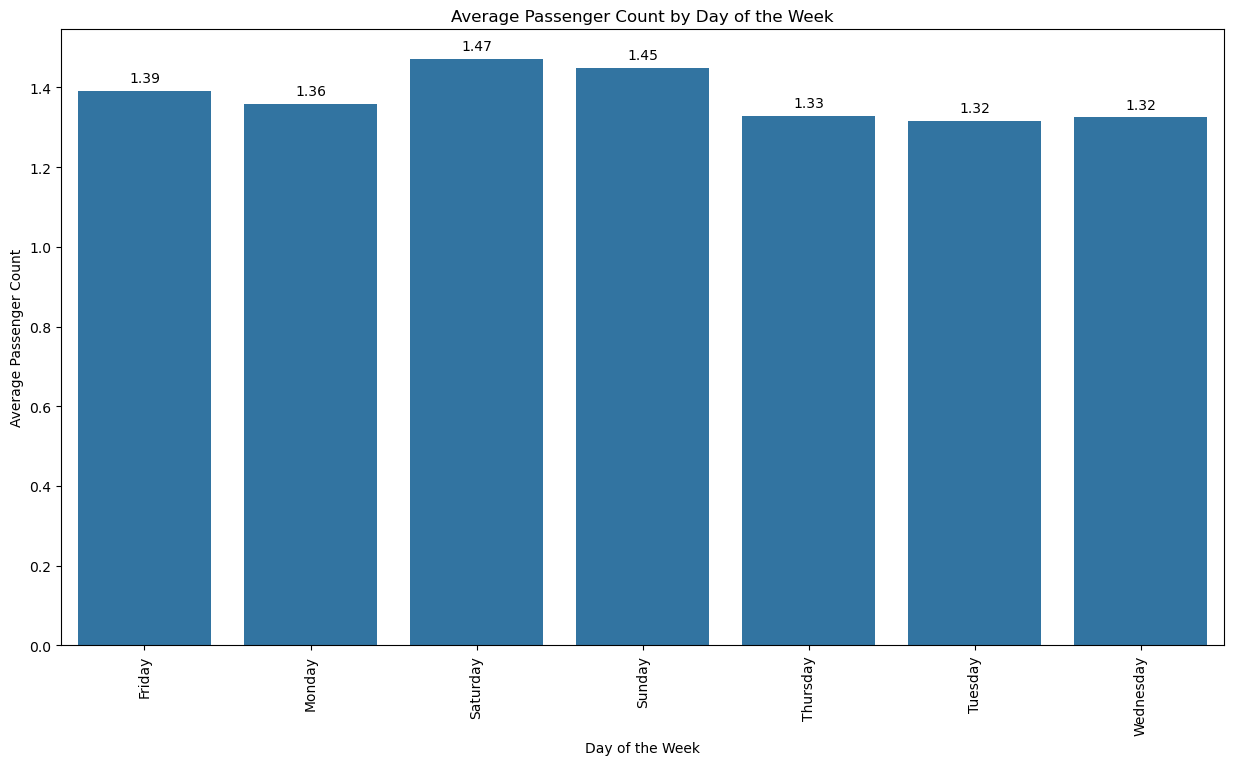

In [80]:
# See how passenger count varies across hours and days

# # Group by hour of the day and calculate the average passenger count
avg_passenger_count_by_hour = merged_df.groupby('pickup_hour')['passenger_count'].mean().reset_index()

# # Group by day of the week and calculate the average passenger count
avg_passenger_count_by_day = merged_df.groupby('pickup_day')['passenger_count'].mean().reset_index()

# # Plot the average passenger count by hours of the day
render_line_plot(avg_passenger_count_by_hour['pickup_hour'], avg_passenger_count_by_hour['passenger_count'], 'Average Passenger Count by Hours of the Day', 'Hour of the Day', 'Average Passenger Count')

# # Plot the average passenger count by days of the week
show_bar_plot(avg_passenger_count_by_day['pickup_day'], avg_passenger_count_by_day['passenger_count'], 'Average Passenger Count by Day of the Week', 'Day of the Week', 'Average Passenger Count', show_data_labels=True)


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

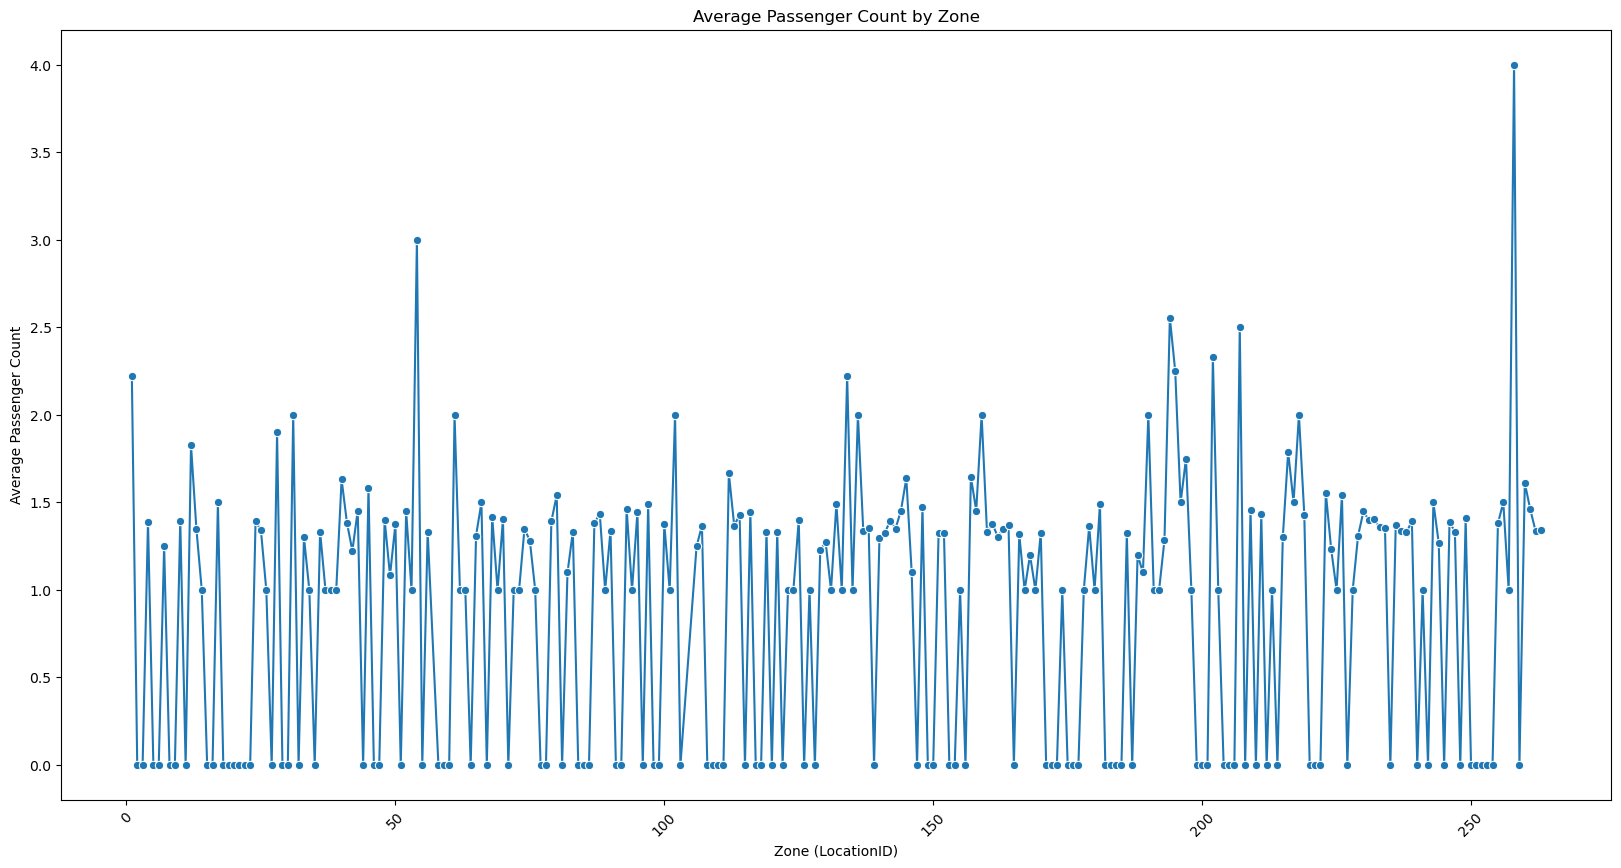

In [81]:
# How does passenger count vary across zones

# Group by PULocationID and calculate the average passenger count for each zone
avg_passenger_count_by_zone = merged_df.groupby('pulocationid')['passenger_count'].mean().reset_index()

# Merge the average passenger count with the zones GeoDataFrame
zones_with_passenger_count = zones.merge(avg_passenger_count_by_zone, left_on='LocationID', right_on='pulocationid', how='left')

# Fill NaN values with 0 (for zones with no trips)
zones_with_passenger_count['passenger_count'].fillna(0, inplace=True)

# Plot the average passenger count for each zone using a bar plot
render_line_plot(zones_with_passenger_count.LocationID, zones_with_passenger_count.passenger_count, 'Average Passenger Count by Zone', 'Zone (LocationID)', 'Average Passenger Count', figsize=(20, 10))


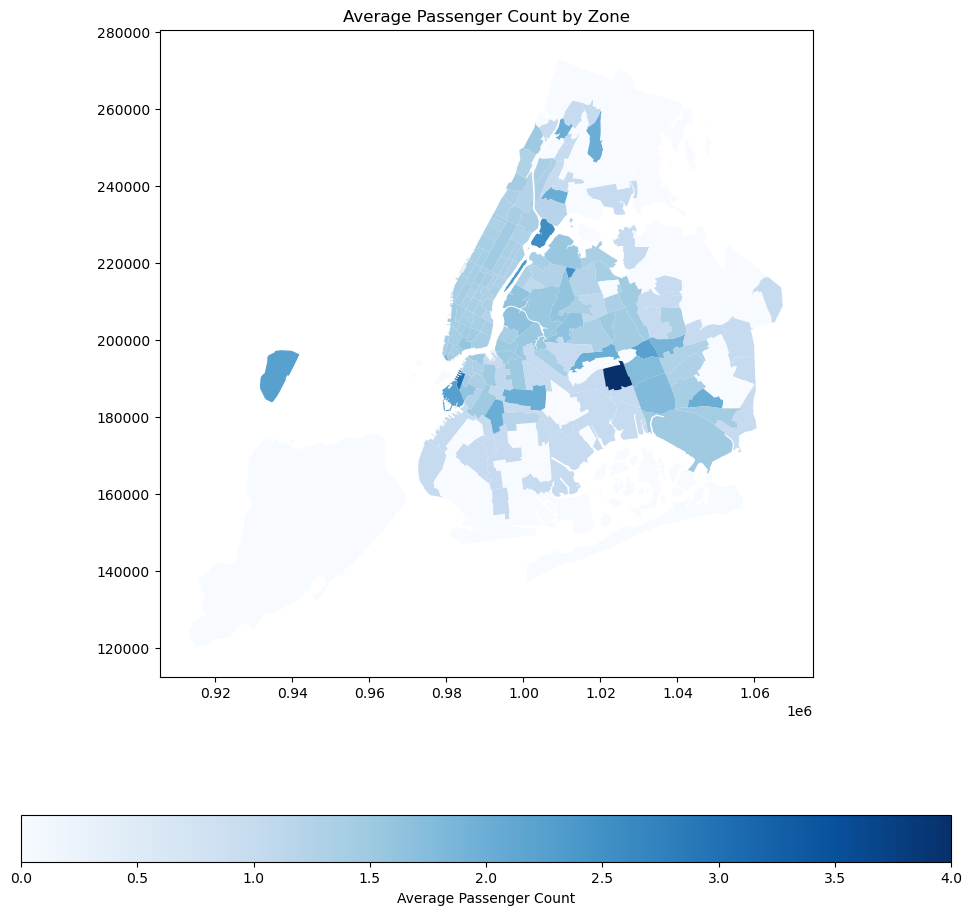

In [82]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.


# Calculate the average passenger count for each zone
avg_passenger_count_by_zone = merged_df.groupby('pulocationid')['passenger_count'].mean().reset_index()

# Merge the average passenger count with the zones_with_trips GeoDataFrame
zones_with_trips = zones_with_trips.merge(avg_passenger_count_by_zone, left_on='LocationID', right_on='pulocationid', how='left')

# Fill NaN values with 0 (for zones with no trips)
zones_with_trips['passenger_count'].fillna(0, inplace=True)

# Plot the average passenger count for each zone using a Geo Plot
zones_with_trips.plot(column='passenger_count', cmap='Blues', legend=True, legend_kwds={'label': "Average Passenger Count", 'orientation': "horizontal"}, figsize=(12, 12))
plt.title('Average Passenger Count by Zone')
plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [83]:
# How often is each surcharge applied?

# Calculate the frequency of each surcharge
surcharge_columns = ['extra', 'congestion_surcharge', 'airport_fee_combined', 'improvement_surcharge']
surcharge_frequencies = merged_df[surcharge_columns].apply(lambda x: (x > 0).sum()).reset_index()
surcharge_frequencies.columns = ['Surcharge', 'Frequency']

# Display the frequency of each surcharge
print("Frequency of each surcharge:")
print(surcharge_frequencies)

print("----------------------------------------------------------------------------------------------------------------")

# Analyze the pickup zones where surcharges are applied more frequently
pickup_surcharge_zones = merged_df[merged_df[surcharge_columns].sum(axis=1) > 0].groupby('pulocationid').size().reset_index(name='surcharge_count')
pickup_surcharge_zones = pickup_surcharge_zones.merge(zones[['LocationID', 'zone']], left_on='pulocationid', right_on='LocationID', how='left').sort_values(by='surcharge_count', ascending=False)

# Display the top pickup zones with surcharges
print("Top pickup zones with surcharges:")
print(pickup_surcharge_zones.head(10))



Frequency of each surcharge:
               Surcharge  Frequency
0                  extra     138077
1   congestion_surcharge     209357
2   airport_fee_combined      18182
3  improvement_surcharge     220479
----------------------------------------------------------------------------------------------------------------
Top pickup zones with surcharges:
     pulocationid  surcharge_count  LocationID                          zone
146           237            10949       237.0         Upper East Side South
97            161            10506       161.0                Midtown Center
75            132             9918       132.0                   JFK Airport
145           236             9788       236.0         Upper East Side North
98            162             8260       162.0                  Midtown East
81            138             8153       138.0             LaGuardia Airport
111           186             7541       186.0  Penn Station/Madison Sq West
84            142           

In [84]:
print("----------------------------------------------------------------------------------------------------------------")
# Analyze the dropoff zones where surcharges are applied more frequently
dropoff_surcharge_zones = merged_df[merged_df[surcharge_columns].sum(axis=1) > 0].groupby('dolocationid').size().reset_index(name='surcharge_count')
dropoff_surcharge_zones = dropoff_surcharge_zones.merge(zones[['LocationID', 'zone']], left_on='dolocationid', right_on='LocationID', how='left').sort_values(by='surcharge_count', ascending=False)

# Display the top dropoff zones with surcharges
print("Top dropoff zones with surcharges:")
print(dropoff_surcharge_zones.head(10))



----------------------------------------------------------------------------------------------------------------
Top dropoff zones with surcharges:
     dolocationid  surcharge_count  LocationID                       zone
229           236            10751       236.0      Upper East Side North
230           237             9687       237.0      Upper East Side South
155           161             8579       161.0             Midtown Center
164           170             6787       170.0                Murray Hill
232           239             6570       239.0      Upper West Side South
136           142             6408       142.0        Lincoln Square East
156           162             6273       162.0               Midtown East
135           141             6201       141.0            Lenox Hill West
223           230             5992       230.0  Times Sq/Theatre District
66             68             5616        68.0               East Chelsea


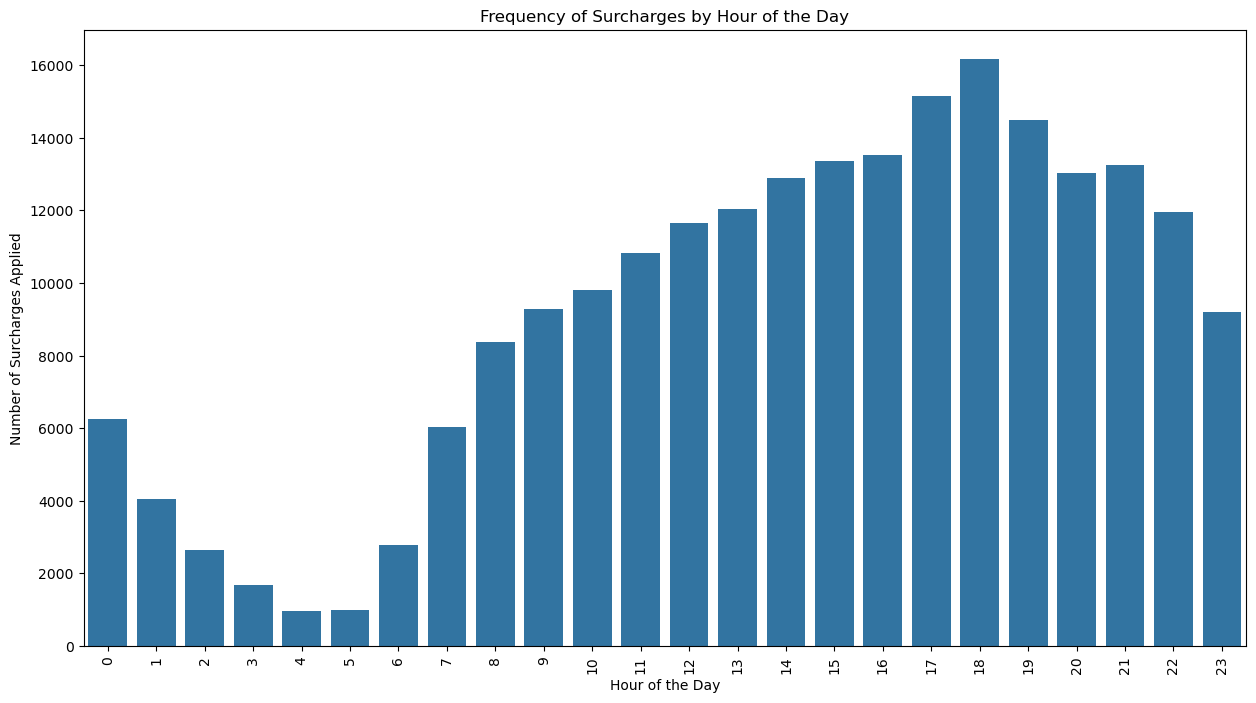

In [85]:
# Analyze the times when surcharges are applied more frequently
merged_df['surcharge_applied_derived'] = merged_df[surcharge_columns].sum(axis=1) > 0
surcharge_by_hour = merged_df.groupby('pickup_hour')['surcharge_applied_derived'].sum().reset_index()

# Plot the frequency of surcharges by hour of the day
show_bar_plot(surcharge_by_hour['pickup_hour'], surcharge_by_hour['surcharge_applied_derived'], 'Frequency of Surcharges by Hour of the Day', 'Hour of the Day', 'Number of Surcharges Applied')

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Based on the analysis of demand patterns and operational inefficiencies, below are some recommendations:

- Allocate more cabs during peak travel hours, especially between morning and evening hours, as trip demand is significantly higher during these periods.

- Increase cab availability in high-demand pickup and dropoff zones identified during the analysis to reduce passenger wait times and improve ride allocation efficiency.

- Use dynamic pricing strategies during peak demand periods and in high-traffic zones to balance demand and supply while improving revenue generation.

- During late night hours, strategically position cabs in zones with consistent ride activity to improve trip availability and reduce idle time.

- Implement intelligent cab repositioning systems to redistribute vehicles toward zones with increasing demand trends in real time.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

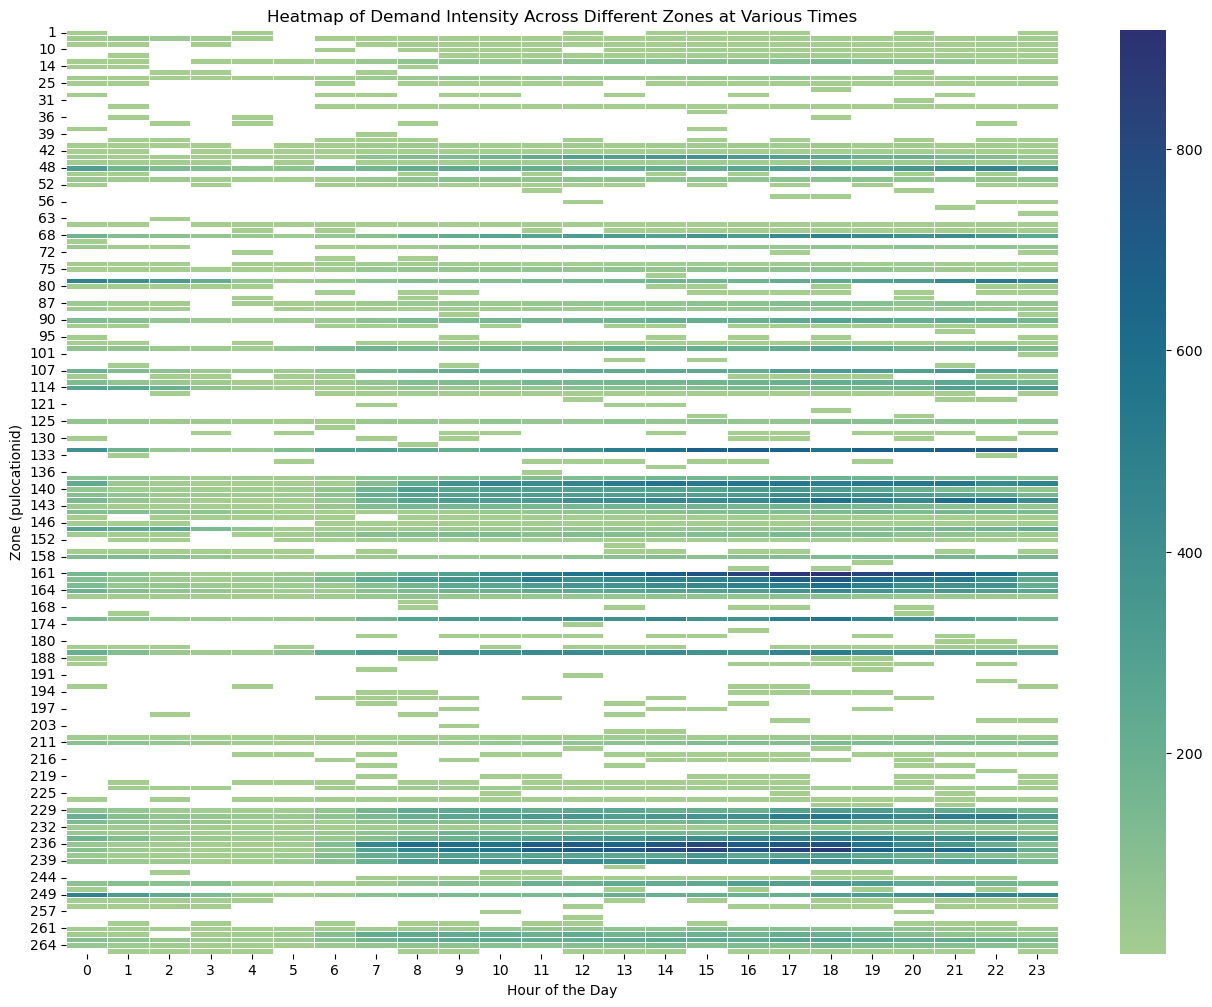

In [86]:
# Aggregate trip counts and passenger counts by zone and time
demand_data = merged_df.groupby(['pulocationid', 'pickup_hour']).agg({
    'passenger_count': 'sum',
    'pulocationid': 'count'
}).rename(columns={'pulocationid': 'trip_count'}).reset_index()

# Pivot the data to create a matrix for the heatmap
heatmap_data = demand_data.pivot(index='pulocationid', columns='pickup_hour', values='trip_count')

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(heatmap_data, cmap="crest", linewidths=0.5)
plt.title('Heatmap of Demand Intensity Across Different Zones at Various Times')
plt.xlabel('Hour of the Day')
plt.ylabel('Zone (pulocationid)')
plt.show()

Suggestions on strategically positioning cabs based on trip trends:

- The demand heatmap highlights specific pickup zones with consistently high ride activity during certain hours of the day.

- Position more cabs in these high-demand zones during peak hours to reduce customer waiting time and improve ride fulfillment rates.

- Monitor hourly demand fluctuations and dynamically adjust cab deployment throughout the day to improve operational efficiency.

- Maintain balanced cab availability across both short-distance and long-distance trip zones to optimize driver utilization and reduce empty travel time.

- Use historical trip trends to proactively position cabs in areas where recurring demand spikes are observed.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Below are recommendations for improving pricing strategy using the insights derived from the analysis:

- Monthly revenue trends indicate comparatively lower revenue during July, August, and September. Promotional pricing or customer discount campaigns during these months may help increase ride demand and overall revenue.

- Average fare per mile varies across different hours of the day and days of the week, suggesting that time-based dynamic pricing strategies may help optimize revenue during peak demand periods.

- High-demand zones and peak travel hours can be prioritized for premium pricing strategies while maintaining competitive pricing during low-demand periods.

- The relationship between trip duration and fare amount suggests that additional operational factors such as traffic conditions and waiting time may influence fare values. These factors can be explored further for future pricing optimization.

- Predictive analytics and machine learning models can be used in future to forecast demand patterns and support more accurate dynamic pricing decisions.